In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['SLATE'],'dust_size_evo/')
os.makedirs(plot_dir, exist_ok=True)

# Appendix Plots

## Dust size distribution change for various processes
Create some useful plots showing how an MRN size distribtuion will change due to each dust process along with general timescales for each

#### Coagulation

NameError: name 'a_bins' is not defined

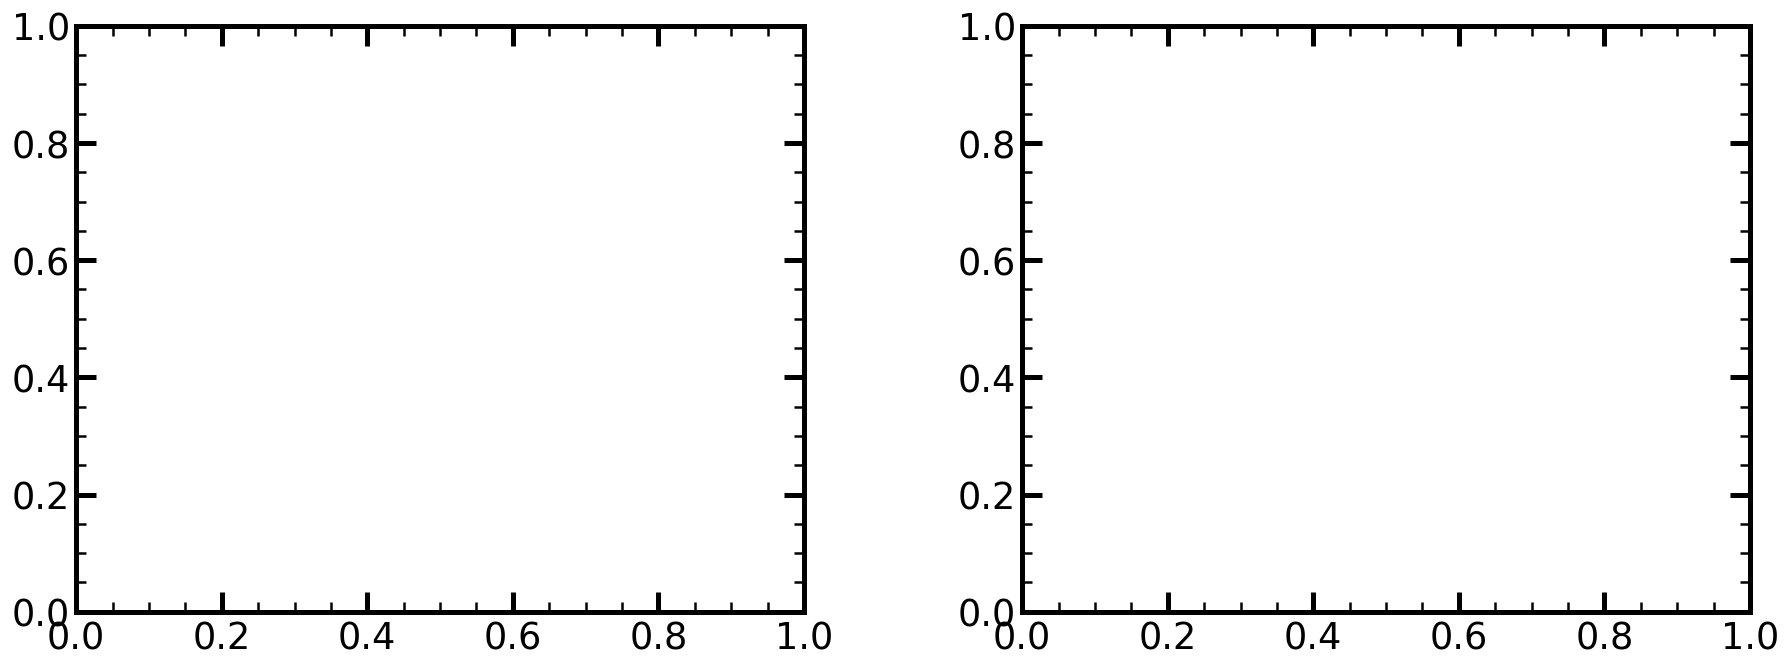

In [2]:
foutname = plot_dir+'analytical_coagulation_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'MC'
dt = 0.01
subcycle_constraint = 'both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, subcycle_constraints=subcycle_constraint, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Shattering
Note the increase at the smallest grain size bin is due to rebinning shattered fragments beyond the minimum grain size back to the smallest bin.

In [ ]:
foutname = plot_dir+'analytical_shattering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32

fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.2
dt = 0.02
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


In [ ]:
foutname = plot_dir+'analytical_shattering_pred_lognorm.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.lognorm_dnda
def init_dmda(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax, args=(0.1,0.6))[0]
init_dm_norm = 1/quad(init_dmda,amin,amax, args=(0.1,0.6))[0]
bin_nums=8


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH


fig.plot_line_data(0,a_bins,init_dnda(a_bins,a_norm=0.1)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins,a_norm=0.1)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(new_dnda(a_bins)[new_dnda(a_bins)>0]),np.power(10,0.5)*np.max(new_dnda(a_bins)[new_dnda(a_bins)>0])])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(new_dmdloga(a_bins)[new_dmdloga(a_bins)>0]),np.power(10,0.5)*np.max(new_dmdloga(a_bins)[new_dmda(a_bins)>0])])


species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.5
dt = 0.005
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Accretion

silicates
Predicted dadt (um/Gyr): [3.53920601 3.53920601 3.53920601 3.53920601 3.53920601 3.53920601
 3.42154044 3.24812054 3.07470063 2.90128073 2.72786082 2.55444092
 2.38102101 2.20760111 2.0341812  1.8607613  1.68734139 1.51392148
 1.34050158 1.16708167 0.99366177 0.82024186 0.64682196 0.47340205
 0.29998215 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603  0.1769603  0.1769603
 0.1769603  0.1769603  0.1769603  0.1769603 ]
Min bin width used for subcyling 6.305212000520076e-05
Total cycles needed 281.0 Subcycle timestep 1.779359430604982e-05
Change in total grain number 0.9999999999918738
Change in total grain mass 8.588131503666448
Initial and final depletion fraction 0.1 

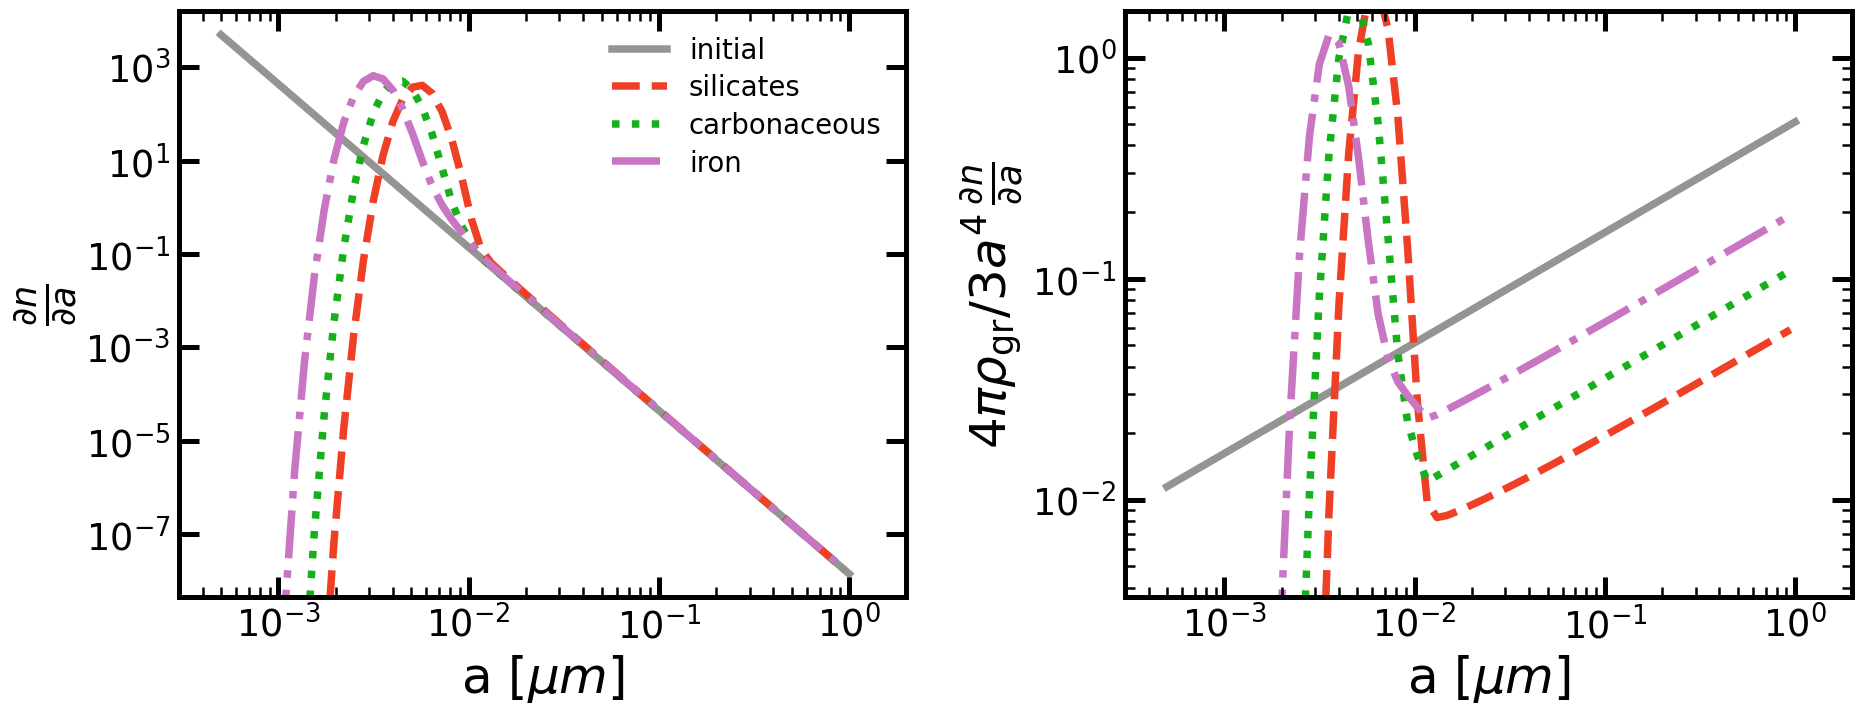

In [10]:
foutname = plot_dir+'analytical_accretion_pred_enh.pdf'

amin=5E-4; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64
a_bins = np.logspace(np.log10(amin),np.log10(amax),bin_nums)


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'CNM'
dt = 0.005
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmda(a_bins)*a_bins, color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


Testing different subcycling prescriptions.
Decided on using the minimum bin.

In [ ]:
foutname = 'analytical_acretion_pred_subcycling_comparisons.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

spec = 'silicates'
ISM_phase = 'CNM'
dt = 0.001
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints=['none','size','min_bin']

for i,subcycle in enumerate(subcycle_constraints):
    print(subcycle)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Thermal Sputtering

In [ ]:
foutname = plot_dir+'analytical_sputtering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'HIM'
dt = 0.1
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Simple visualizations for dust processes diagram

These are parameters every diagram uses.

In [69]:
amin=5E-4; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
# Normalize by the total mass
def init_dmdloga_normed(a):
    return init_dmdloga(a)*init_dm_norm
# Normalize by total number
def init_dnda_normed(a):
    return init_dnda(a)*init_dn_norm

num_bins = 64
a_vals = np.logspace(np.log10(amin),np.log10(amax),num=num_bins+1)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/num_bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(num_bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2

discretized_dnda = init_dnda_normed(a_centers)


dmdloga_limits = [np.power(10,-0.5)*np.min(init_dmdloga_normed(a_vals)),np.power(10,0.75)*np.max(init_dmdloga_normed(a_vals))]


colors = ["xkcd:dark royal blue","xkcd:forest green","xkcd:indian red",]
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linestyles = ['--','-.',':','-']
linewidth = 3.75*config.BASE_LINEWIDTH

species = ['silicates','carbonaceous','iron']
init_depl = 0.4 # initial depletion of key element for dust species


##### Stardust

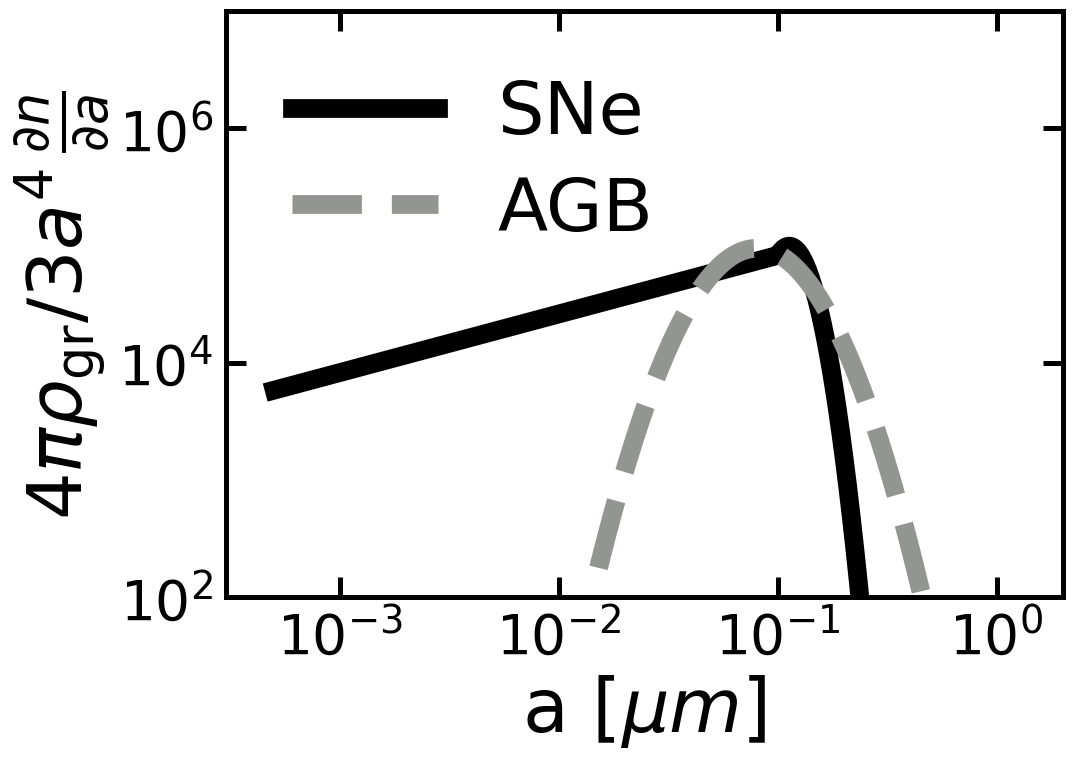

In [4]:
foutname = plot_dir+'grain_size_SNe_diagram.pdf'


def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)

grain_size_utils.SNe_dmdloga(amin*config.um_to_cm)

# Use this to normalize dm/dloga by total grain mass
SNe_dmdloga_norm = 1/quad(grain_size_utils.SNe_dmdloga,amin*config.um_to_cm,amax*config.um_to_cm)[0]
def SNe_dmdloga_normed(a):
    return grain_size_utils.SNe_dmdloga(a*config.um_to_cm)*SNe_dmdloga_norm

AGB_dmdloga_norm = 1/quad(grain_size_utils.AGB_dmdloga,amin*config.um_to_cm,amax*config.um_to_cm)[0]
def AGB_dmdloga_normed(a):
    return grain_size_utils.AGB_dmdloga(a*config.um_to_cm)*AGB_dmdloga_norm

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=[1E2,1E7], rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,SNe_dmdloga_normed(a_vals), color='xkcd:black',linestyle='-', linewidth=linewidth,label="SNe", zorder=-2)

fig.plot_line_data(0,a_vals,AGB_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='--', linewidth=linewidth,label="AGB", zorder=-2)


fig.set_all_legends(max_cols=1,rescale_font=2)
fig.save(foutname)

##### Accretion

silicates
Predicted dadt (um/Gyr): [2.35947068 2.35947068 2.35947068 2.21808638 1.98685984 1.7556333
 1.52440676 1.29318022 1.06195368 0.83072714 0.5995006  0.36827406
 0.13704752 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 89.0 Subcycle timestep 5.617977528089888e-05
Change in total grain number 0.9999999999968244
Change in total grain mass 2.496242412376165
Initial and final depletion fraction 0.4 0.9984969649504658
carbonaceous
Predicted dadt (um/Gyr): [0.98807859 0.98807859 0.98807859 0.92575471 0.8238273  0.7218999
 0.61997249 0.51804508 0.41611767 0.31419026 0.21226286 0.11033545
 0.00840804 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        

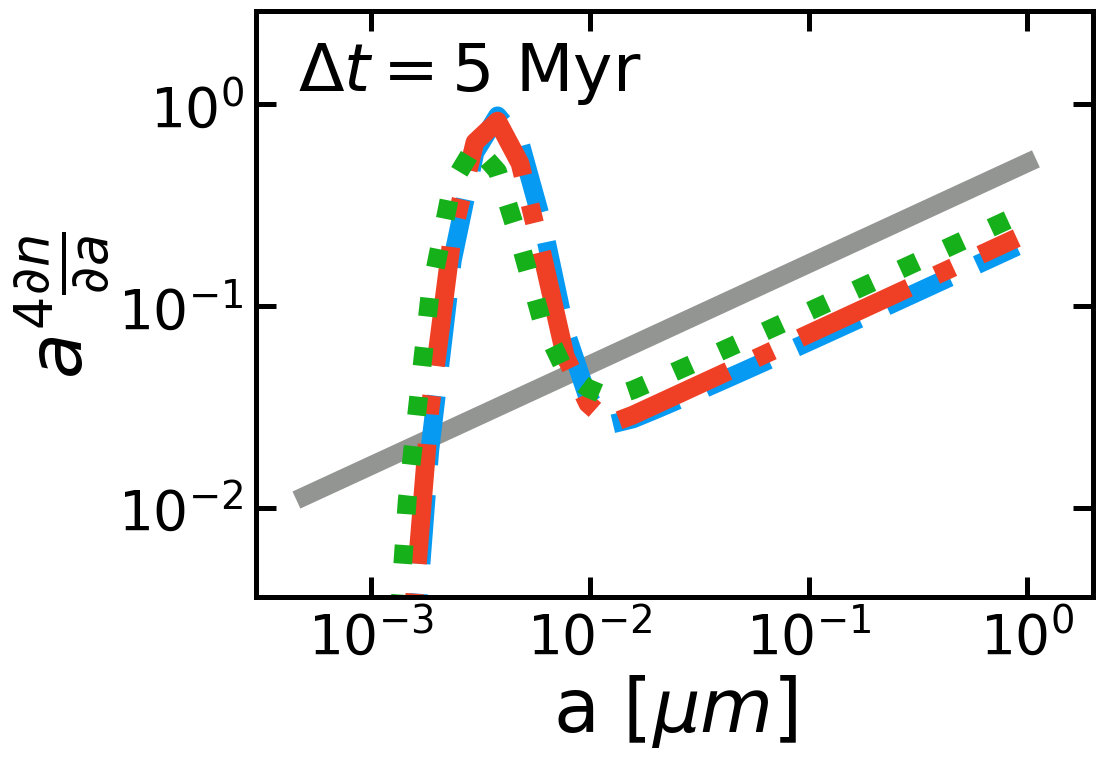

In [48]:
foutname = plot_dir+'grain_size_accretion_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.005
Z_scaling = 1
subcycle_constraints='min_bin'
bin_nums=64

# Include Coulomb enhancement
include_Cenh=True

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da', y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True,y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    dnda, dmdloga, depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt, a_vals, discretized_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl, include_Cenh=include_Cenh, Z_scaling=Z_scaling)


    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.save(foutname)

Predicted dadt (um/Gyr): [23.59470676 23.59470676 23.59470676 22.18086384 19.86859844 17.55633303
 15.24406762 12.93180222 10.61953681  8.3072714   5.995006    3.68274059
  1.37047518  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534
  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534
  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534
  1.17973534  1.17973534]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 1761.0 Subcycle timestep 5.678591709256104e-06
Change in total grain number 0.9999999999968189
Change in total grain mass 2.499999999999994
Initial and final depletion fraction 0.4 0.9999999999999993
Predicted dadt (um/Gyr): [22.48741167 20.3860081  18.28460453 16.18320096 14.08179739 11.98039382
  9.87899025  7.77758668  5.67618311  3.57477954  1.47337597  1.17973534
  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534
  1.17973534  1.17973534  1.17973534  1.17973534  1.17973534  1.

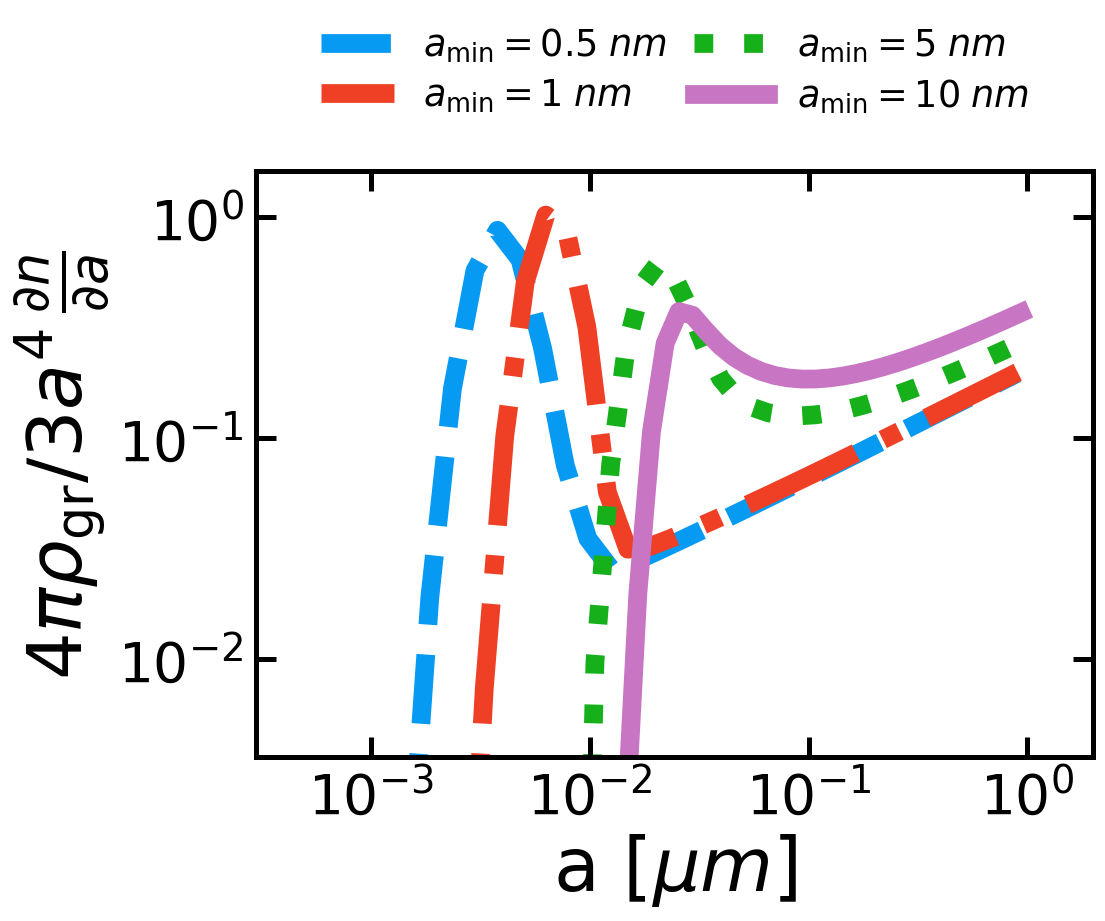

In [14]:
foutname = plot_dir+'accretion_for_varying_amin.pdf'
ISM_phase = 'CNM'
dt = 0.01
Z_scaling = 10
subcycle_constraints='min_bin'
bin_nums=64

# Include Coulomb enhancement
include_Cenh=True

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da', y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)


amins= [5E-4,1E-3,5E-3,1E-2]
for i,amin in enumerate(amins):

    amax=1E0
    init_dnda = gse.MRN_dnda
    def init_dmda(a):
        return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
    def init_dmdloga(a):
        return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
    # Use this to normalize dn/da by total grain number and dm/da by total grain mass
    init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
    init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
    # Normalize by the total mass
    def init_dmdloga_normed(a):
        return init_dmdloga(a)*init_dm_norm
    # Normalize by total number
    def init_dnda_normed(a):
        return init_dnda(a)*init_dn_norm

    num_bins = 32
    a_vals = np.logspace(np.log10(amin),np.log10(amax),num=num_bins+1)
    a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/num_bins)
    a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(num_bins+1)])
    a_centers = (a_edges[1:]+a_edges[:-1])/2

    discretized_dnda = init_dnda_normed(a_centers)



    dnda, dmdloga, depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt, a_vals, discretized_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species='silicates', depl_frac=init_depl, include_Cenh=include_Cenh, Z_scaling=Z_scaling)

    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=r'$a_{\rm min} = %g \; nm$'%(amin*1E3))

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
#fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')
fig.set_outside_legend()

fig.save(foutname)

##### Sputtering

silicates
Predicted dadt (um/Gyr): [-0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587
 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587
 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587
 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587
 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587 -0.39994587
 -0.39994587 -0.39994587]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 2984.0 Subcycle timestep 0.0003351206434316354
Change in total grain number 8.690124481988384e-08
Change in total grain mass 0.08711296293724624
Initial and final depletion fraction 0.1 0.008711296293724665
carbonaceous
Predicted dadt (um/Gyr): [-0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689
 -0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689
 -0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689 -0.25318689
 -0.25318689 -0.25318689 -0.253186

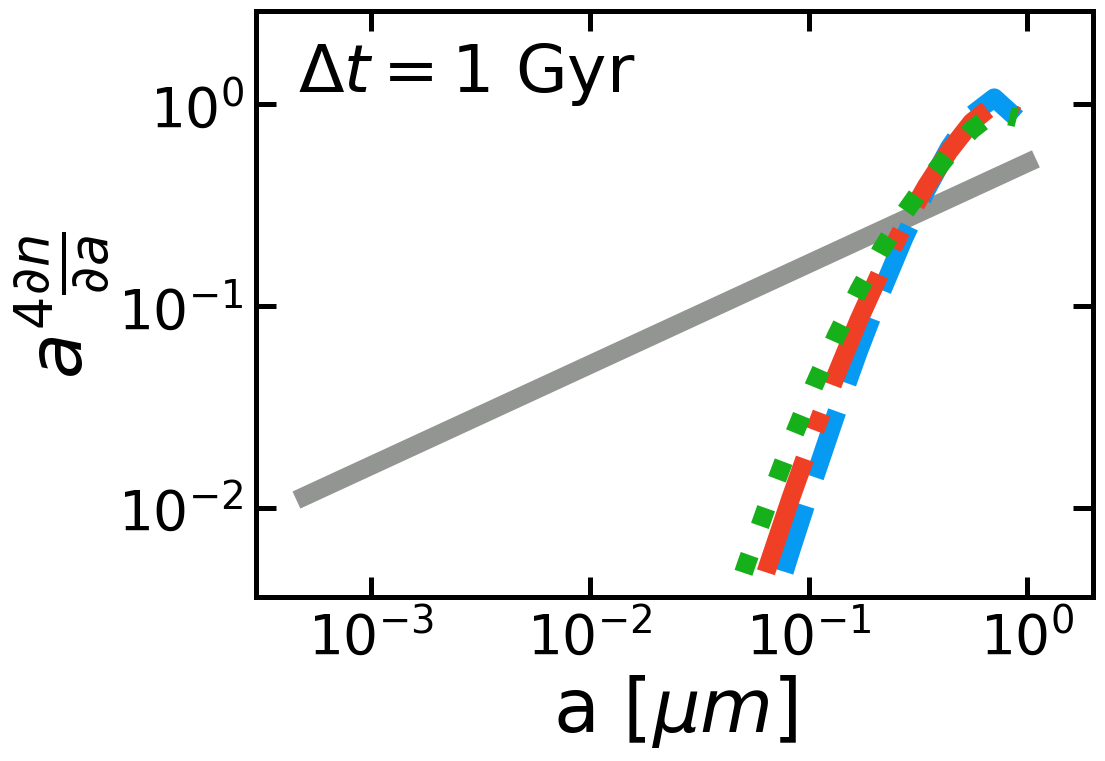

In [26]:
foutname = plot_dir+'grain_size_sputtering_diagram.pdf'

ISM_phase = 'HIM'
dt = 1
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True, y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    dnda, dmdloga, depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt, a_vals, discretized_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, Z_scaling=Z_scaling)

    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)
    

text = r'$\Delta t = %1.0f $ Gyr'%(dt)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Shattering

silicates
Final changes
Total mass fraction changed in given timestep 0.995875137303959
Total number fraction changed in given timestep 1.2720356816334364
carbonaceous
Need to subcycle for 2 cycle
	 Number moved between bins 7.398449435638309e-08
	 Mass moved between bins 0.14715736097027227
	 Change if we did not subcycle
	 Total mass fraction moved in given timestep 0.9895244186587318
	 Total number fraction change in given timestep 1.6438770786145074
Final changes
Total mass fraction changed in given timestep 0.9883983057583968
Total number fraction changed in given timestep 1.6653895350269143
iron
Need to subcycle for 2 cycle
	 Number moved between bins 8.447637111992899e-08
	 Mass moved between bins 0.18487628885869742
	 Change if we did not subcycle
	 Total mass fraction moved in given timestep 0.9880008125791735
	 Total number fraction change in given timestep 1.9606091696610972
Final changes
Total mass fraction changed in given timestep 0.9862307444936292
Total number fraction 

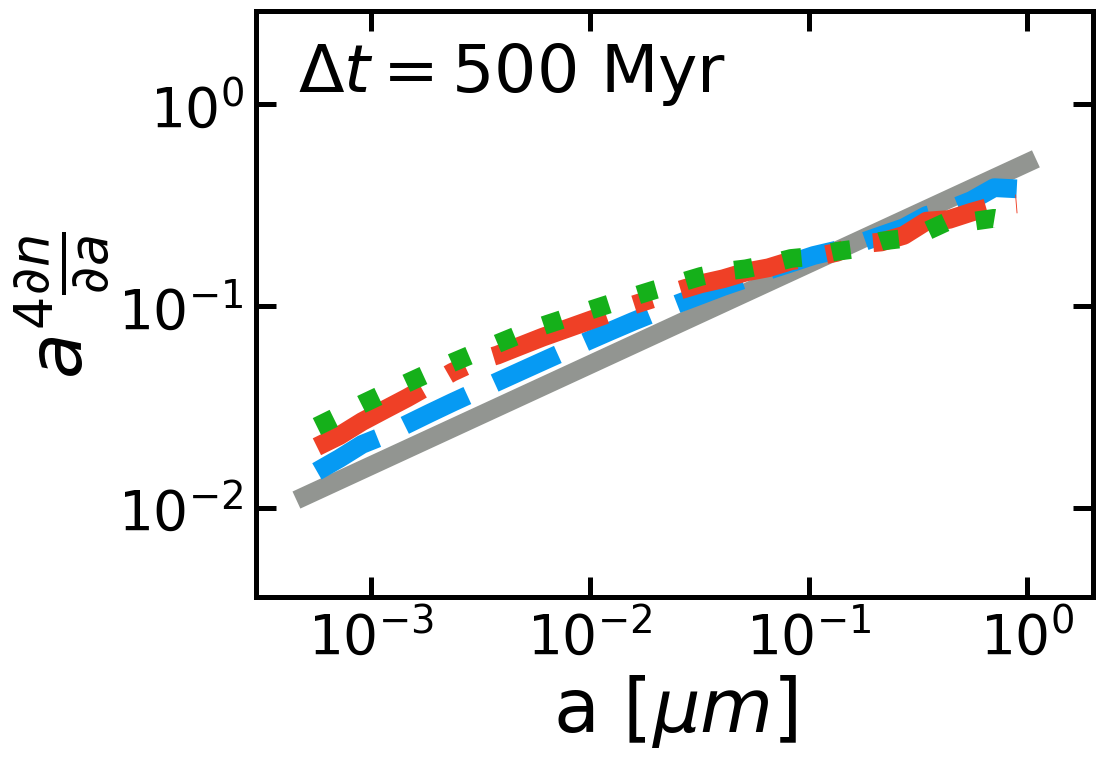

In [28]:
foutname = plot_dir+'grain_size_shattering_diagram.pdf'

ISM_phase = 'WIM'
dt = 0.5
Z_scaling=1
subcycle_constraints='both'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True, y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    dnda, dmdloga = gse.change_in_grain_distribution_from_shat_coag(dt, a_vals, discretized_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=0.99, Z_scaling=Z_scaling)

    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Coagulation

silicates
Need to subcycle for 10 cycle
	 Number moved between bins 0.9973632473110771
	 Mass moved between bins 0.052133240496280556
	 Change if we did not subcycle
	 Total mass fraction moved in given timestep 4.542682481661563
	 Total number fraction change in given timestep 0.06847399472524987
Final changes
Total mass fraction changed in given timestep 2.071964730206137
Total number fraction changed in given timestep 0.028707828437068515
carbonaceous
Need to subcycle for 10 cycle
	 Number moved between bins 0.9998646097017589
	 Mass moved between bins 0.11295461471396606
	 Change if we did not subcycle
	 Total mass fraction moved in given timestep 6.957197887306356
	 Total number fraction change in given timestep 0.002938808605863767
Final changes
Total mass fraction changed in given timestep 2.3562122591009174
Total number fraction changed in given timestep 0.000987929393759911
iron
Need to subcycle for 10 cycle
	 Number moved between bins 0.9999772060246459
	 Mass moved between b

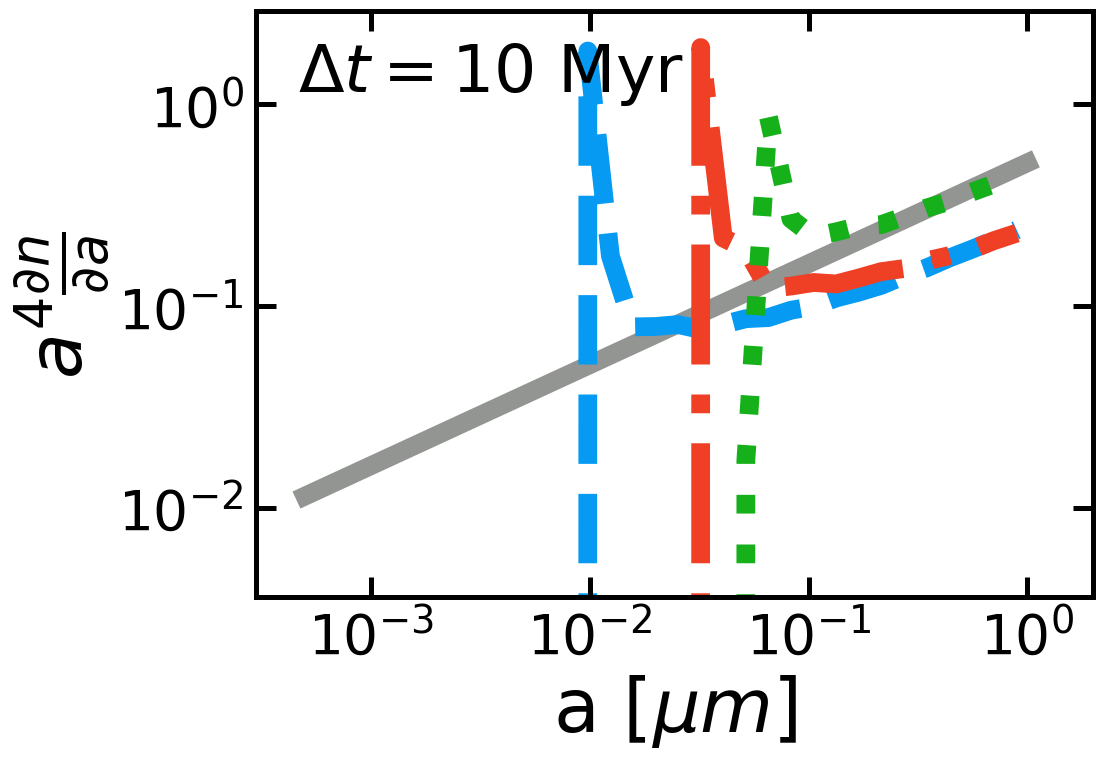

In [29]:
foutname = plot_dir+'grain_size_coagulation_diagram.pdf'

ISM_phase = 'MC'
dt = 0.01
Z_scaling=1
subcycle_constraints='both'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True, y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    dnda, dmdloga = gse.change_in_grain_distribution_from_shat_coag(dt, a_vals, discretized_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=0.99, Z_scaling=Z_scaling)

    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### SNe Shocks

###### New Routine with shattering and sputtering

0.3988228101837391
0.33232568035062404
0.3695761459931256


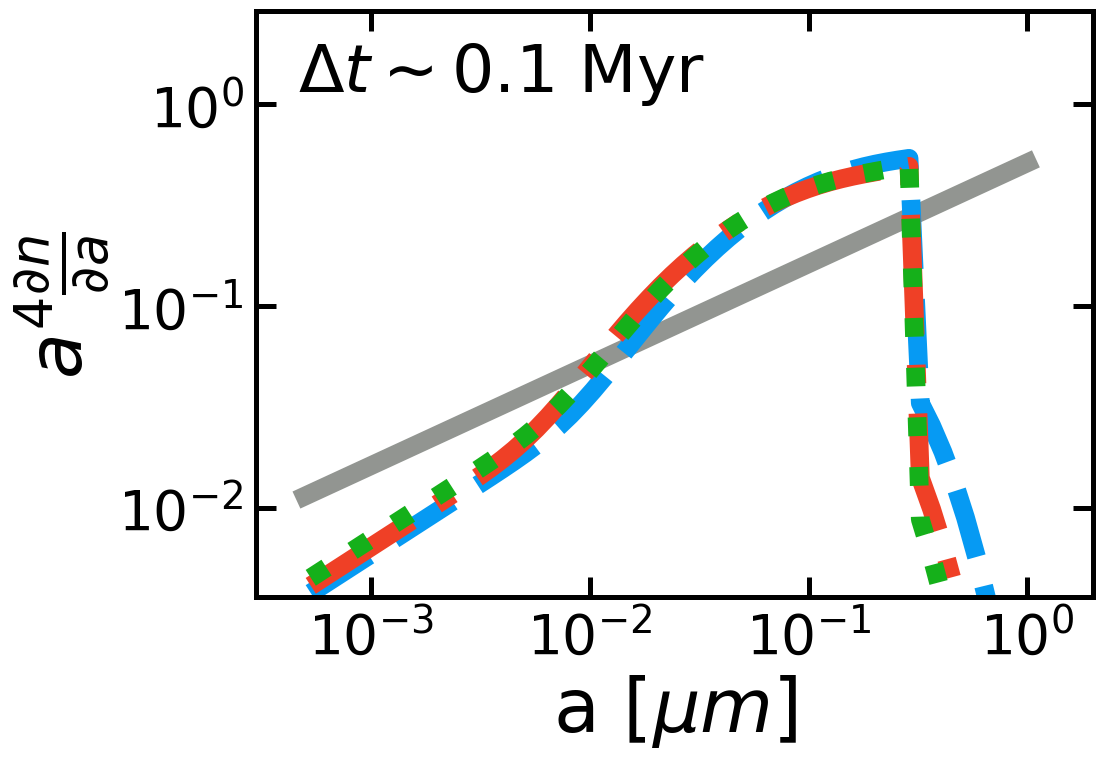

In [71]:

foutname = plot_dir+'grain_size_SNe_shock_diagram.pdf'


dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True, y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing()
SNe_proc.set_numerical_dnda(init_dnda_normed(a_centers), a_centers, a_edges, normalize=False)

for i, spec in enumerate(species):
    f_SNe_dest,dnda_SNe_dest,dmda_SNe_dest = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', species=spec, delta_sput = 2, delta_shat = 0, a_sput=0.05)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe_dest,amin,amax)[0]
    fig.plot_line_data(0,a_centers,dmda_SNe_dest(a_centers)*a_centers/(total_mass), color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)
    print(f_SNe_dest)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

###### Old routine with only sputtering

0.44925658968919757
0.44925658968919757
0.44925658968919757


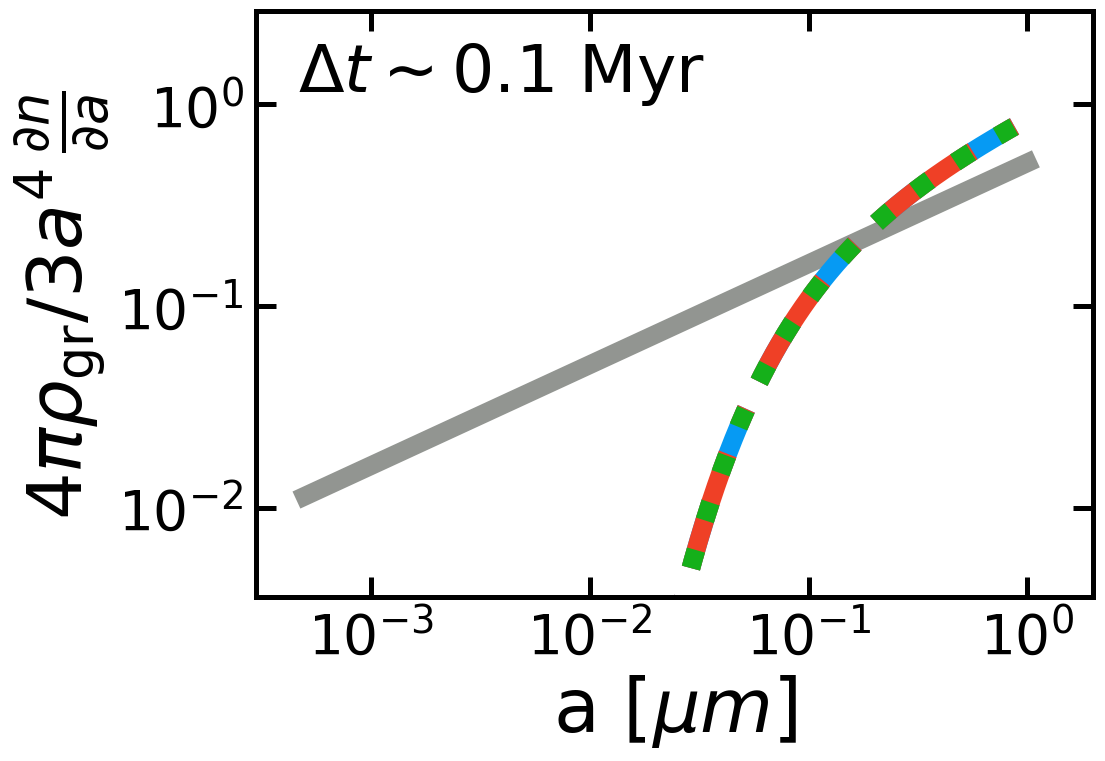

In [58]:

foutname = plot_dir+'grain_size_SNe_shock_only_sput_diagram.pdf'

# Set limits for size distribution
dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True, y_label=r'$a^4 \frac{\partial n}{\partial a}$')

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle='-', linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing()
SNe_proc.set_numerical_dnda(init_dnda_normed(a_centers), a_centers, a_edges, normalize=False)

delta_sput_only=2
a_sput = 0.05; # microns

for i, spec in enumerate(species):
    f_SNe_dest,dnda_SNe_dest,dmda_SNe_dest = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_only, delta_shat = 0, a_sput=a_sput)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe_dest,amin,amax)[0]
    fig.plot_line_data(0,a_centers,dmda_SNe_dest(a_centers)*a_centers/(total_mass), color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)
    print(f_SNe_dest)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### Resolution Checks on Accretion and Coagulation

silicates
Step 0: Accretion
Predicted dadt (um/Gyr): [2.35947068 2.35947068 2.35947068 2.21808638 1.98685984 1.7556333
 1.52440676 1.29318022 1.06195368 0.83072714 0.5995006  0.36827406
 0.13704752 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 9.0 Subcycle timestep 5.555555555555556e-05
Change in total grain number 0.9999999999988258
Change in total grain mass 1.2851966179346848
Initial and final depletion fraction 0.4 0.514078647173874
Step 0: Coagulation
Need to subcycle for 6 cycle
	 Number moved between bins 0.023154703227212917
	 Mass moved between bins 0.5126838846687459
	 Change if we did not subcycle
	 Total mass fraction moved in given timestep 0.49040952507627883
	 Total number fraction change in given timestep 0.9796151934315855
Final c

/N/slate/cchoban/codes/crc_scripts/src/crc_scripts/analytical_models/grain_size_evo.py:226: RuntimeWarning: divide by zero encountered in scalar divide
  dt_acc = epsilon_cycle*a1_width/dadt_0;


Final changes
Total mass fraction changed in given timestep 0.9895878557622227
Total number fraction changed in given timestep 0.9142486365858129
Step 6: Accretion
Predicted dadt (um/Gyr): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 1 Subcycle timestep 0.0005
Change in total grain number 1.0
Change in total grain mass 1.0
Initial and final depletion fraction 1 1
Step 6: Coagulation
Final changes
Total mass fraction changed in given timestep 0.991118035755125
Total number fraction changed in given timestep 0.9163223028748851
Step 7: Accretion
Predicted dadt (um/Gyr): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 1 Subcycle timestep 0.0005
Change in total grain number 1.0
Change in total grain mass 1.0
Initial and final depletion fr

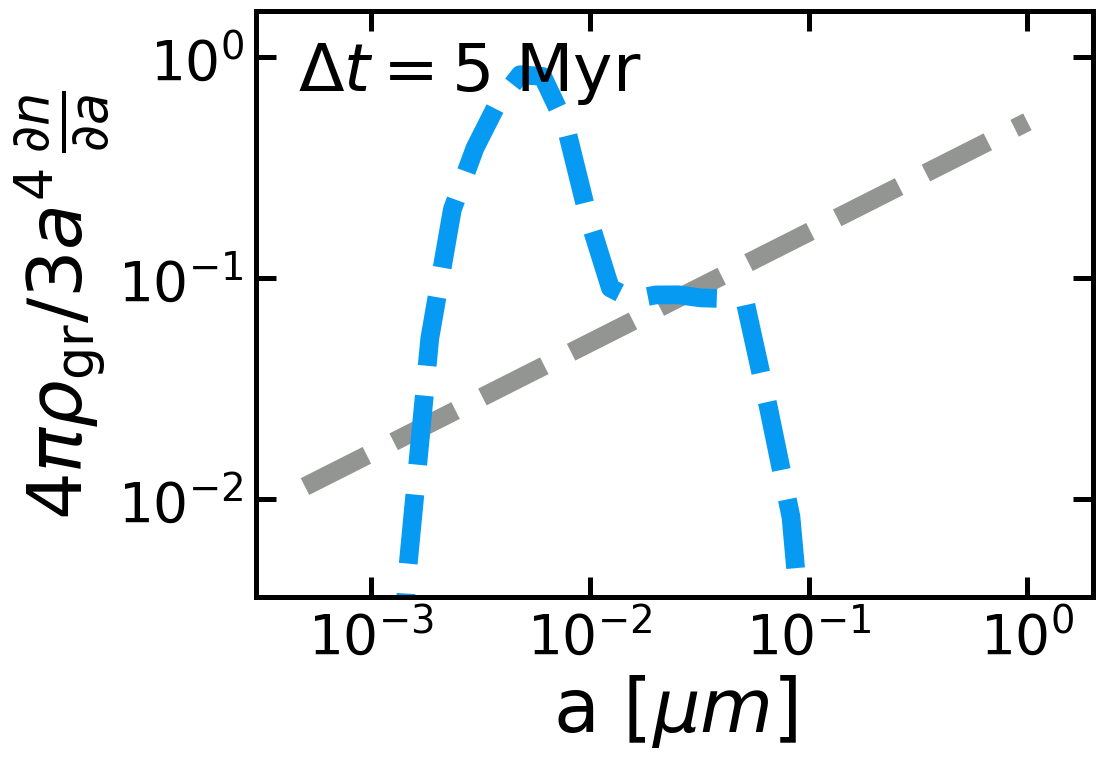

In [113]:
foutname = plot_dir+'acc_coag_diagram.pdf'
dt = 0.005
N_timesteps = 10
subcycle_constraints='min_bin'
bin_nums=64

# Include Coulomb enhancement
include_Cenh=True
no_vcoag=True

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da', y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

final_dndna = None;
final_dmdloga = None;
final_depl=None



for i,spec in enumerate(species):
    if spec !='silicates': continue
    print(spec)
    step_depl = init_depl
    step_dndna = discretized_dnda
    for j in range(N_timesteps):
        print("Step %i: Accretion"%j)
        dnda, dmdloga, new_depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt/N_timesteps,a_vals, step_dndna, ISM_phase='CNM', subcycle_constraints=subcycle_constraints, species=spec, depl_frac=step_depl, include_Cenh=include_Cenh)
        print("Step %i: Coagulation"%j)
        dnda, dmdloga = gse.change_in_grain_distribution_from_shat_coag(dt/N_timesteps, a_vals, dnda, ISM_phase='DENSE', subcycle_constraints=subcycle_constraints, species=spec, depl_frac=new_depl_frac, Z_scaling=1*Z_scaling, no_vcoag=no_vcoag)
        # print("Step %i: Shattering"%j)
        # dnda, dmdloga = gse.change_in_grain_distribution_from_shat_coag(dt/N_timesteps, a_vals, dnda, ISM_phase='WIM', subcycle_constraints=subcycle_constraints, species=spec, depl_frac=new_depl_frac, Z_scaling=100*Z_scaling)

        # print("Step %i: SNe Dest"%j)
        # SNe_proc = gse.SNe_Dust_Processing()
        # SNe_proc.set_numerical_dnda(dnda, a_centers, a_vals, normalize=False)
        # delta_sput_only=2*((dt/N_timesteps)/0.1)
        # a_sput = 0.05; # microns
        # f_SNe_dest,dnda_SNe_dest,dmda_SNe_dest = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_only, delta_shat = 0, a_sput=a_sput)
        # print("SNe fraction destroyed", f_SNe_dest)
        # dnda = dnda_SNe_dest(a_centers)

        f_SNe_dest=0

        step_depl = new_depl_frac * (1-f_SNe_dest)
        step_dndna = dnda
    
    final_dnda = dnda
    final_dmdloga = dmdloga
    final_depl = new_depl_frac


    fig.plot_line_data(0,a_centers,final_dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth*(j+1)/N_timesteps,label=spec)

print(final_depl)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.save(foutname)

silicates
Predicted dadt (um/Gyr): [2.35947068 2.35947068 2.35947068 2.21808638 1.98685984 1.7556333
 1.52440676 1.29318022 1.06195368 0.83072714 0.5995006  0.36827406
 0.13704752 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353 0.11797353
 0.11797353 0.11797353]
Min bin width used for subcyling 0.00013405537968470344
Total cycles needed 89.0 Subcycle timestep 5.617977528089888e-05
Change in total grain number 0.9999999999968244
Change in total grain mass 2.496242412376165
Initial and final depletion fraction 0.4 0.9984969649504658
0 dM [-2.89998955e+12 -5.23514598e+21 -6.61215148e+25 -6.30214199e+28
 -8.41400448e+30 -2.34064326e+32 -2.04496810e+33 -6.98981288e+33
 -1.06113863e+34  3.88250430e+35  6.17297471e+35  1.66608486e+35
  2.35459945e+34  4.86751305e+33  4.05187861e+33  3.60417853e+33
  3.28012362e+33  2.12014632e+33  2.00545029e+33  8.73774791e+32
  8

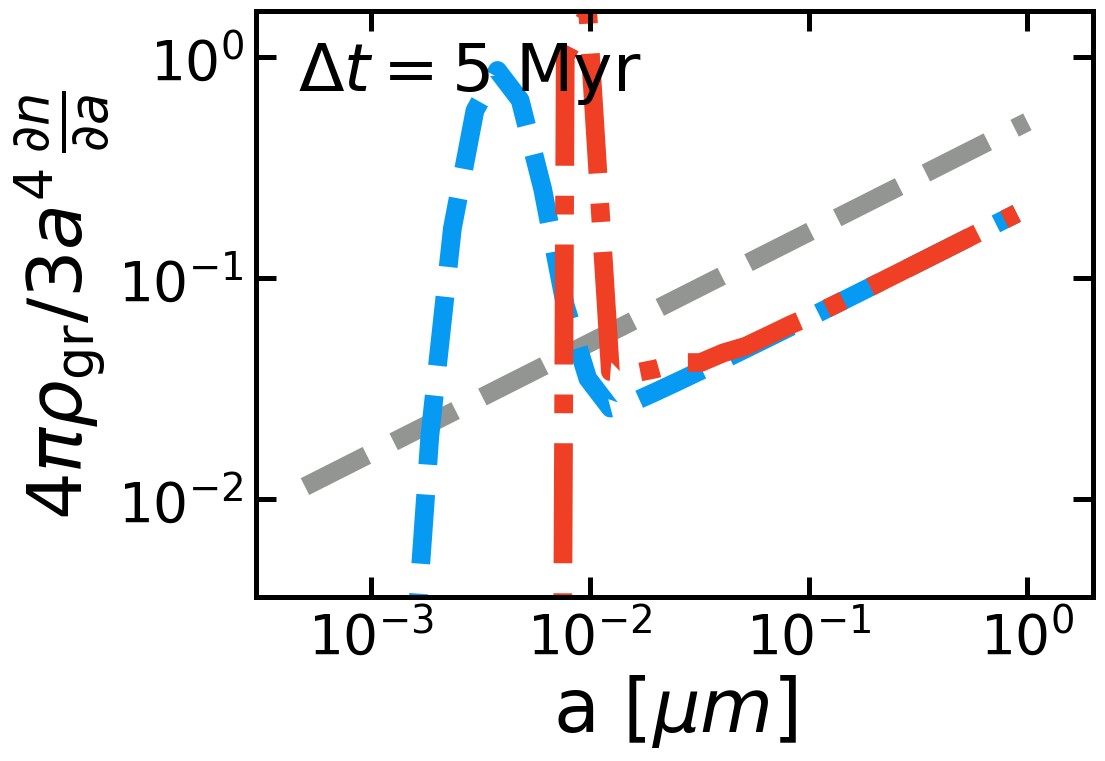

In [96]:
foutname = plot_dir+'acc_coag_diagram.pdf'
dt = 0.005
Z_scaling=1
subcycle_constraints='min_bin'
bin_nums=32

# Include Coulomb enhancement
include_Cenh=True

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da', y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    if spec !='silicates': continue
    print(spec)

    dnda, dmdloga, depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt,a_vals, discretized_dnda, ISM_phase='CNM', subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl, include_Cenh=include_Cenh)

    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)
        
    dnda, dmdloga = gse.change_in_grain_distribution_from_shat_coag(dt*10, a_vals, dnda, ISM_phase='DENSE', subcycle_constraints=subcycle_constraints, species=spec, depl_frac=depl_frac, Z_scaling=Z_scaling)


    fig.plot_line_data(0,a_centers,dmdloga, color=colors[i+1],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.save(foutname)

[0.00011436 0.00012136 0.00012878 0.00013666 0.00014502 0.00015389
 0.00016331 0.0001733  0.0001839  0.00019516 0.00020709 0.00021977
 0.00023321 0.00024748 0.00026262 0.00027869 0.00029574 0.00031383
 0.00033303 0.00035341 0.00037503 0.00039797 0.00042232 0.00044816
 0.00047558 0.00050467 0.00053555 0.00056831 0.00060308 0.00063998
 0.00067913 0.00072068 0.00076478 0.00081156 0.00086122 0.00091391
 0.00096982 0.00102915 0.00109212 0.00115893 0.00122984 0.00130508
 0.00138493 0.00146966 0.00155957 0.00165499 0.00175624 0.00186369
 0.00197771 0.00209871 0.00222711 0.00236336 0.00250796 0.00266139
 0.00282422 0.00299701 0.00318037 0.00337494 0.00358142 0.00380054
 0.00403306 0.0042798  0.00454164 0.0048195  0.00511436]
silicates
Predicted dadt (um/Gyr): [2.35947068 2.35947068 2.35947068 2.35947068 2.35947068 2.35947068
 2.28102696 2.16541369 2.04980042 1.93418715 1.81857388 1.70296061
 1.58734734 1.47173407 1.3561208  1.24050753 1.12489426 1.00928099
 0.89366772 0.77805445 0.66244118 0.5

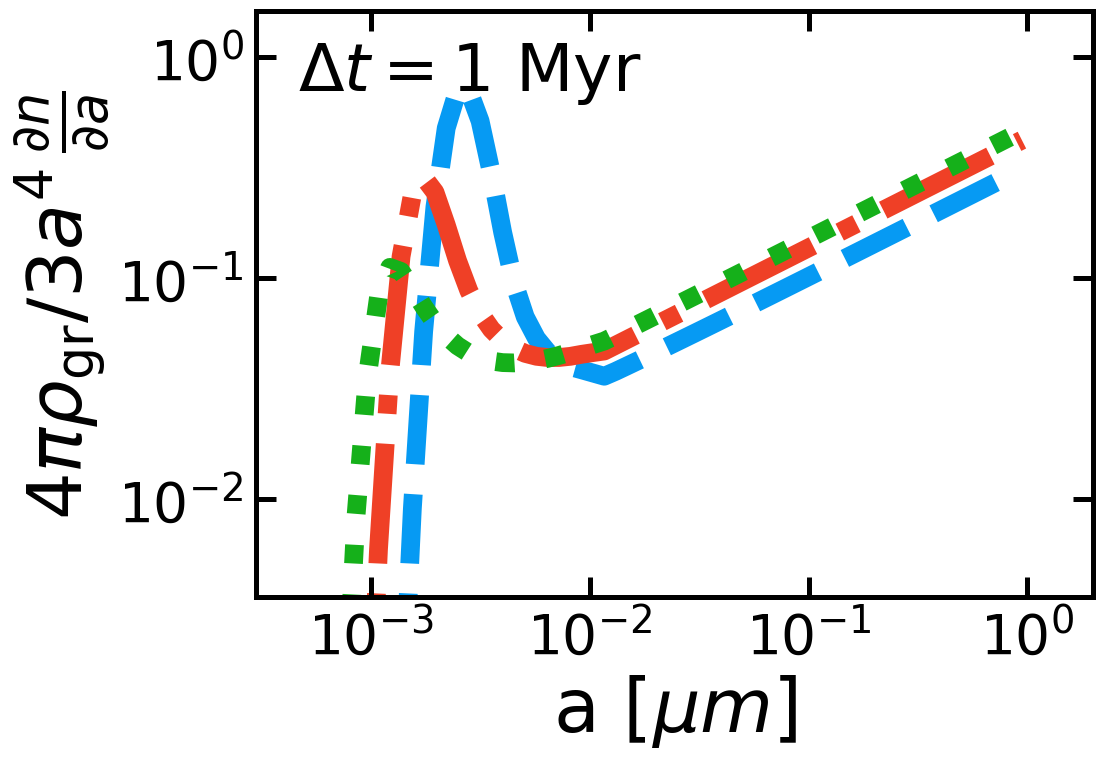

In [31]:
foutname = plot_dir+'acc_coag_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.001
subcycle_constraints='min_bin'
bin_nums=64

# Include Coulomb enhancement
include_Cenh=True

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da', y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)
print(init_dmdloga_normed(a_vals)) 

for i,spec in enumerate(species):
    print(spec)
    a_vals = np.logspace(np.log10(amin),np.log10(amax),bin_nums+1)*config.um_to_cm
    a_centers = (a_vals[1:]+a_vals[:-1])/2
    discretized_dnda = init_dnda(a_centers)
    a_bins, dnda, dmda, depl_frac  = gse.change_in_grain_distribution_from_acc_sput(dt,init_dnda = discretized_dnda, a_vals=a_vals, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl, include_Cenh=include_Cenh)


    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

## Thermal Erosion Rate Comparison

In [ ]:

Tsput = 2E6; 
T_limits = [3E4,5E7]
T = np.logspace(np.log10(T_limits[0]), np.log10(T_limits[1]), 100)
Y_Tsai = 3.2E-18 / (np.power((Tsput/T),2.5) + 1) * config.cm_to_um / config.sec_to_Gyr;

x = np.log10(T)
Y_carb = np.power(10,-226.85176513236104 + 133.44188274964907*x - 32.57239140566398*np.power(x,2) + 4.005662246063896*np.power(x,3) - 0.247470977981441*np.power(x,4) + 0.0061211887939359045*np.power(x,5)) / 1E-9
Y_sil = np.power(10,-226.94973608304852 + 127.94268281713853*x - 29.91964844780188*np.power(x,2) + 3.5354022742488267*np.power(x,3) - 0.21055294512995676*np.power(x,4) + 0.0050362487746130735*np.power(x,5)) / 1E-9
Y_Fe = np.power(10,-156.87812803401695 + 82.10982096578688*x - 18.237504267725893*np.power(x,2) + 2.0691984369187524*np.power(x,3) - 0.11933080830511887*np.power(x,4) + 0.00277875641831501*np.power(x,5)) / 1E-9
N=5
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

y_label = r'$Y_{\rm dust}\;(\mu m \; {\rm Gyr}^{-1} \;{\rm cm^{3}})$'
fig = Figure(1)
fig.set_axis(0, 'T', 'erosion_rate', x_lim=T_limits, x_log=True, y_label=y_label, y_lim=[np.max(Y_sil)*1E-3, 2*np.max(Y_sil)], y_log=True)

fig.plot_line_data(0, T, Y_Tsai, color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH, label='Tsai+95')
i=0
fig.plot_line_data(0, T, Y_sil, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='silicates')
i=1
fig.plot_line_data(0, T, Y_carb, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='carbon')
i=2
fig.plot_line_data(0, T, Y_Fe, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='iron')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(plot_dir+'dust_erosion_rate.pdf')

## Sub-Resolved Gas Clumping

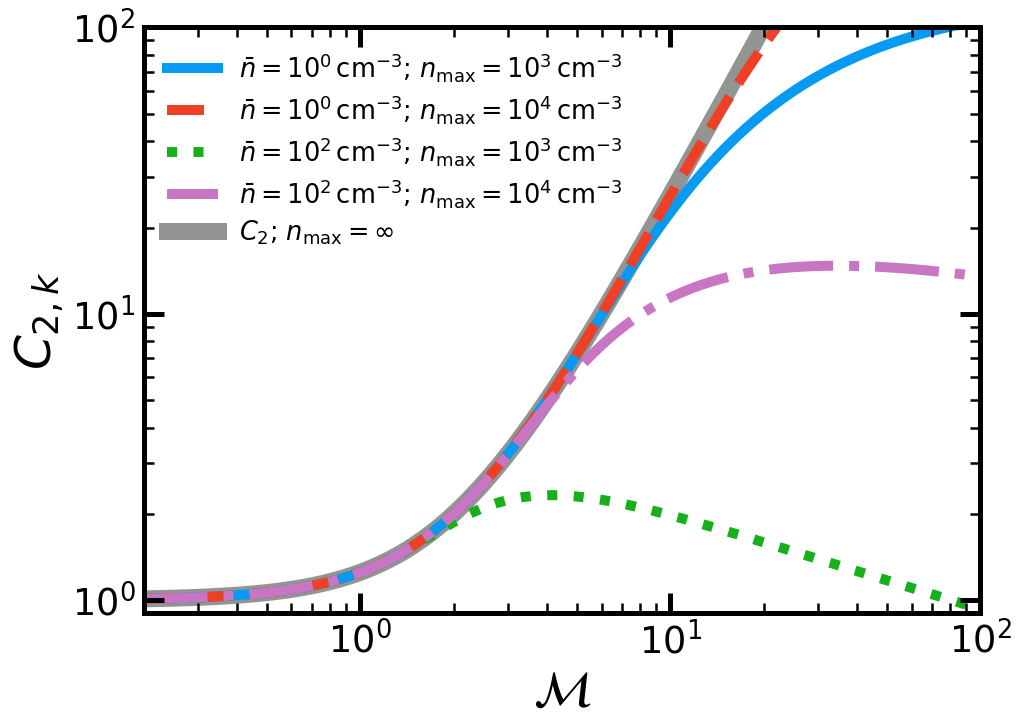

In [4]:
from scipy.special import erfc,erf

foutname = 'clumping_factor.pdf'

M_limits = [0.2,100]
C_limits = [0.9,100]
nmaxs = [1E3,1E4,1E3,1E4]
ns=[1E0,1E0,1E2,1E2]


M = np.logspace(np.log10(M_limits[0]),np.log10(M_limits[1]),100)
b = 0.5 # ratio of solenoidal to compressive turbulence
sigma = np.sqrt(np.log(1+b*b*M*M))

N = len(nmaxs)

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

x_label = r'$\mathcal{M}$'
y_label = r'$C_{2,k}$'
fig = Figure(1)
fig.set_axis(0, 'M', 'clumping_factor', x_lim=M_limits, x_log=True, x_label=x_label, y_label=y_label, y_lim=C_limits, y_log=True)



for i in range(N):
    nmax=nmaxs[i]
    n=ns[i]
    clumping_factor = np.exp(sigma*sigma)/2 * erfc((3/2*sigma*sigma-np.log(nmax/n)) / (np.sqrt(2)*sigma))
    label = r'$\bar{n}=10^{%i}\,{\rm cm^{-3}}$; $ n_{\rm max}=10^{%i}\,{\rm cm^{-3}}$'%(np.log10(n),np.log10(nmax))
    fig.plot_line_data(0,M,clumping_factor,label=label,linestyle=linestyles[i],color=colors[i], linewidth=linewidth)
    
    if i == N-1:
        T_clumping_factor = np.exp(sigma*sigma)
        label = r'$C_2$; $ n_{\rm max}=\infty$'
        fig.plot_line_data(0,M,T_clumping_factor,label=label,linestyle='-',color='xkcd:grey', linewidth=1.7*linewidth,zorder=-3)

fig.set_all_legends(rescale_font=0.7,max_cols=1)

fig.save(plot_dir+foutname)

## Turbulence Driven Grain Velocity

In [ ]:

foutname = plot_dir+'Lebreuilly23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, ISM_phase='CNM', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,ISM_phase='MC', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'Li21_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)
    
for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'HC23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:
v1 = 1
v2 = 1

N=10000


xlim= [0.1,100]
ylim = [0,1]

colors = config.LINE_COLORS[:2]
linestyles = config.LINE_STYLES[:2]
linewidth = 2*config.BASE_LINEWIDTH

labels = ['Li+21','Hirashita+09']

y_label = 'CDF'
x_label = r'$v_{\rm rel}$'
fig = Figure(1)
fig.set_axis(0, 'vrel', 'prob', x_lim=xlim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=False)

# Determine relative velocities by taking the difference of x, y, and z components
vrel = np.zeros(N)
for i in range(3):
    v1i=np.random.normal(0,v1*v1/3,1000)
    v2i=np.random.normal(0,v2*v2/3,1000)
    vrel = np.power(v1i-v2i,2)
vrel=np.sqrt(vrel)

#fig.plot_1Dhistogram(0,vrel,bin_log=True)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[0])


impact_angle = np.random.uniform(-1,1,N)
vrel = np.sqrt(v1*v1 + v2*v2 - 2*v1*v2*impact_angle)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[1])

fig.set_all_legends()



## Coagulation Velocity

In [ ]:
foutname=plot_dir+'coagulation_velocity.pdf'

alim= [0.001,1]
a_vals = np.logspace(np.log10(alim[0]),np.log10(alim[1]),100)*1E-4
ylim = [5E-4,1E1]

colors = config.LINE_COLORS[:3]
linestyles = config.LINE_STYLES[:3]
linewidth = config.LINE_WIDTHS[[0,3]]


y_label = r'$v_{\rm coag}$ (km/s)'
x_label = r'$a_j$ ($\mu m$)'

fig = Figure(1)
fig.set_axis(0, 'vcoag', 'aj', x_lim=alim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=True)

species = ['silicates','carbonaceous','iron']
# The grain sizes for the target grain
aks = np.array([0.1,0.001])*1E-4 # cm

for i in range(len(species)):
    
    # Get species properties
    spec_props = gse.dust_species_properties(species[i])
    dust_atomic_weight = spec_props['dust_atomic_weight']
    key_mass = spec_props['key_mass']
    key_abundance = spec_props['key_abundance']
    key_num_atoms = spec_props['key_num_atoms'] 
    P1 = spec_props['P1']
    v_shat = spec_props['v_shat']/1E5 # km/s
    poisson = spec_props['poisson']
    youngs = spec_props['youngs']
    gamma = spec_props['gamma']
    rho_c = spec_props['rho_c']

    for j, ak in enumerate(aks):
        v_coag = gse.v_coagulation(ak,a_vals,rho_c, poisson, youngs, gamma)/1E5 # km/s

        fig.plot_line_data(0,a_vals/1E-4,v_coag,label=species[i],linestyle=linestyles[i],color=colors[i], linewidth=linewidth[j])

        if j==0:
            if i == len(species)-1: vshat_label=r'$v_{\rm shat}$'
            else: vshat_label=None
            vshat_line = mlines.Line2D(alim,[v_shat,v_shat], c='xkcd:grey',label=vshat_label,linewidth=config.BASE_LINEWIDTH,linestyle=linestyles[i],zorder=-3)
            fig.add_artist(0,vshat_line)
        
        if i == len(species)-1:
            new_label=r'$a_k=%g \, \mu m$'%(ak*1E4)
            fig.plot_line_data(0,[config.EPSILON],[config.EPSILON],label=new_label,linestyle='-',color='xkcd:black', linewidth=linewidth[j])



fig.set_all_legends(rescale_font=1/1.25,ncols=2,loc='lower left')

fig.save(foutname)

# Analytical Testing

## SNe Dust Destruction

### Sputtering and shattering efficiency functions

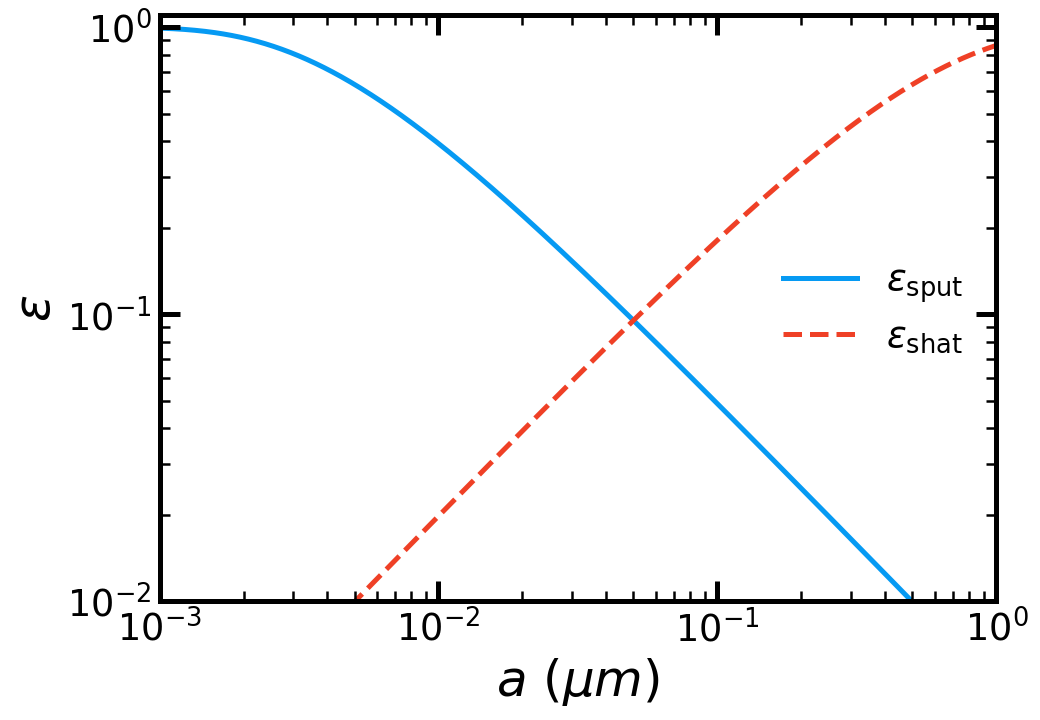

In [110]:
N = 5

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH


a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.1;
delta_shat = 0.1;
a_limit = [1E-3,1E0]
a = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),500)


y_label = r'$ \epsilon $'
x_label = r'$a$ ($\mu m$)'
eff_limits = [1E-2,1.1]
fig = Figure(1)
fig.set_axis(0, 'a', 'eff', x_lim=a_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=eff_limits, y_log=True)


def eff_sput(a):
        return (1 - np.exp(-(delta_sput / (a/a_sput))))
def eff_shat(a):
        return (1 - np.exp(-(delta_shat * (a/a_shat))))

i=0
fig.plot_line_data(0,a,eff_sput(a),label=r'$\epsilon_{\rm sput}$',color=colors[i], linestyle=linestyles[i])
i=1
fig.plot_line_data(0,a,eff_shat(a),label=r'$\epsilon_{\rm shat}$',color=colors[i], linestyle=linestyles[i])
fig.set_all_legends()

### Total dust destruction fraction
This tests the shattering+sputtering and shattering+sputting+shattering routines for varying sputtering and shattering efficiencies

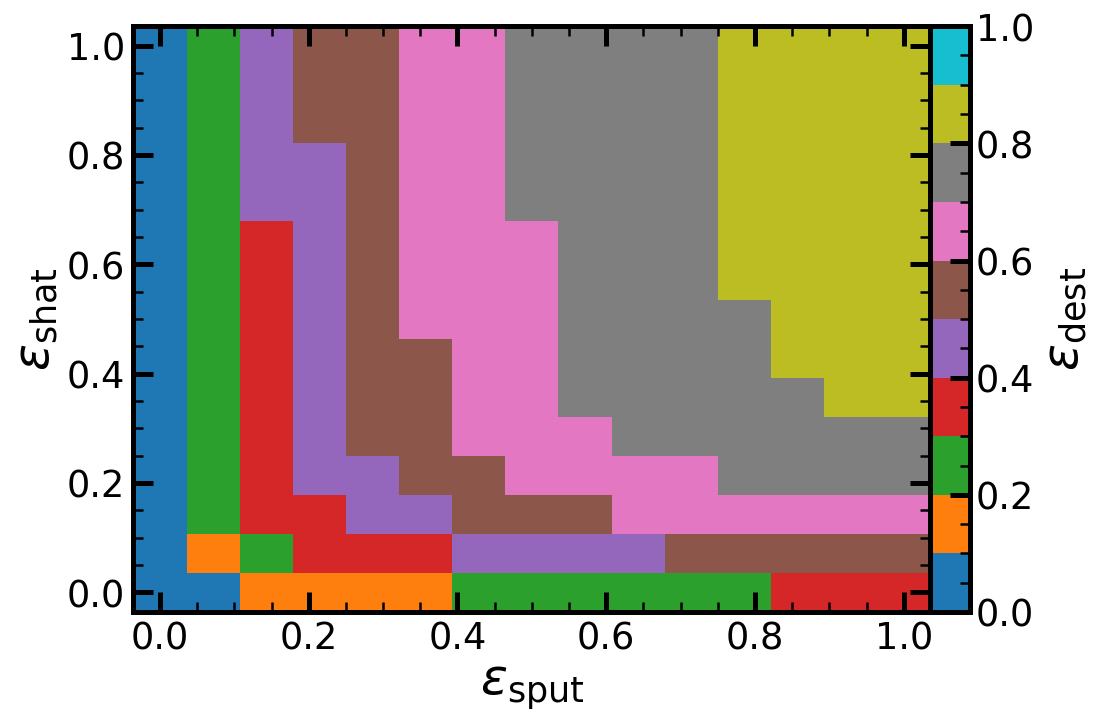

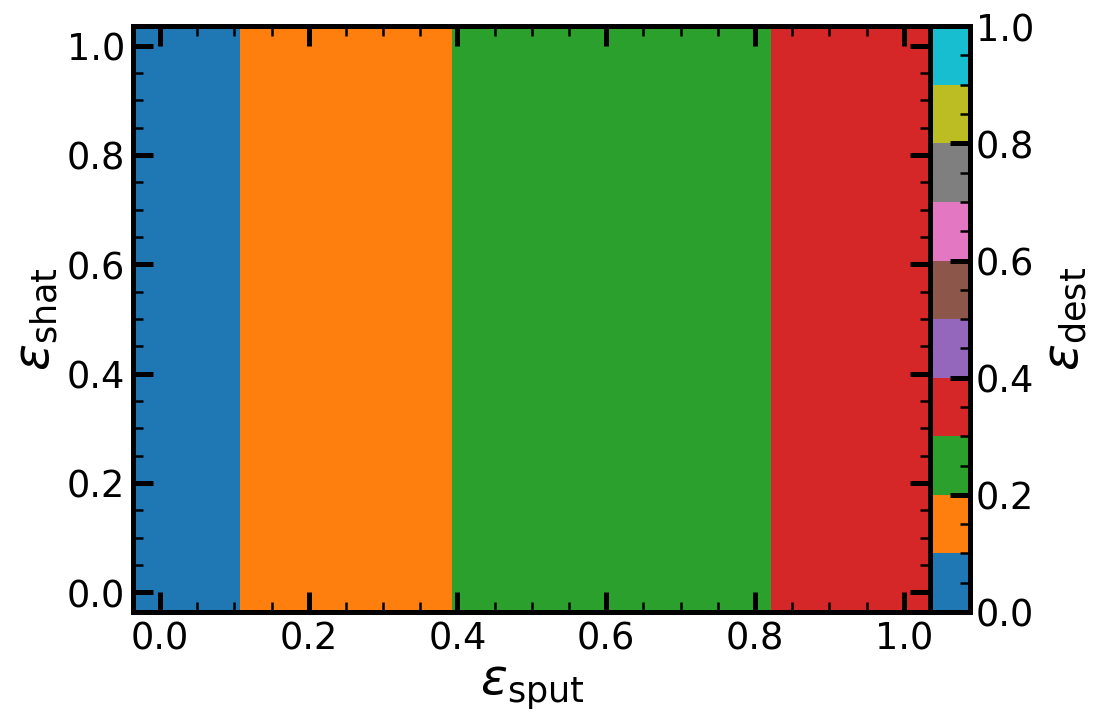

In [2]:
# Set limits for size distribution
amin = 1E-3
amax=1E0
bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

a_sput = 0.05; # microns
a_shat = 0.05;
a_frag_max = a_shat

init_dnda=gse.MRN_dnda

N=15
eff_shats = np.linspace(0,1,N)
eff_sputs = eff_shats
f_dest = np.zeros((N,N))

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)



color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

approx='shat_sput_shat'

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp, delta_shat = eff_sh, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)

approx='sput'

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp,a_sput=a_sput)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)


### Comparing SNe grain size destruction models

SNe 1
Sh+Sp+Sh Dest Frac 2: 0.5876137619012677
	 init mass 0.999963 fin mass 0.412386
Sp Only Dest Frac: 0.5633934366887478
	 init mass 0.999963 fin mass 0.436607
Nozawa+06 Dest Frac: 0.5757858979010781
	 init mass 0.999963 fin mass 0.424214


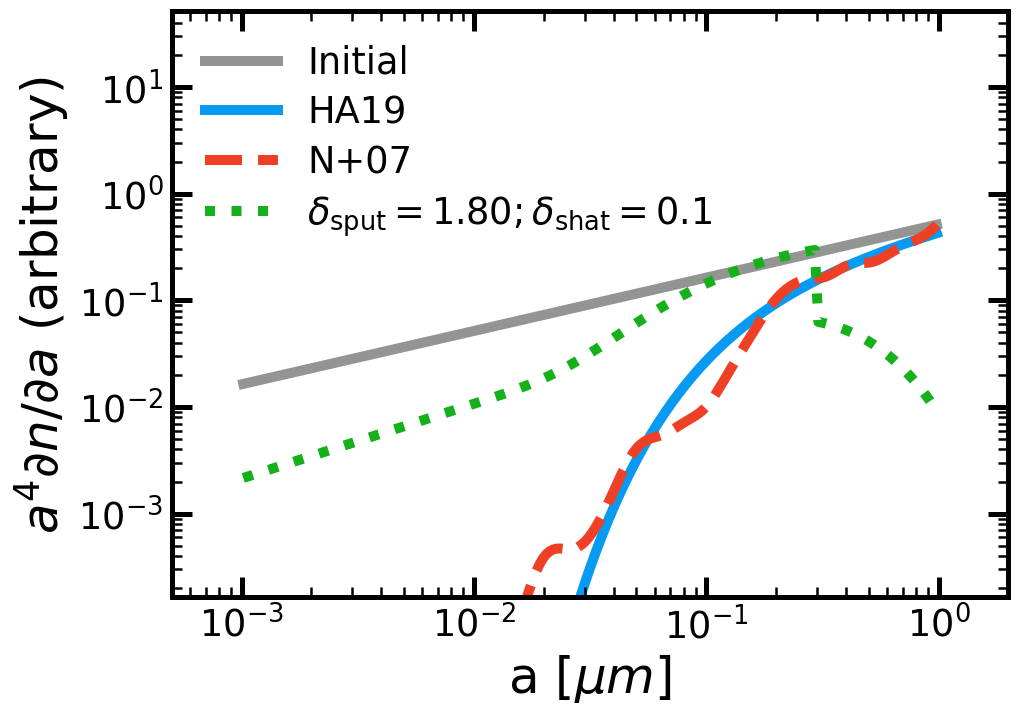

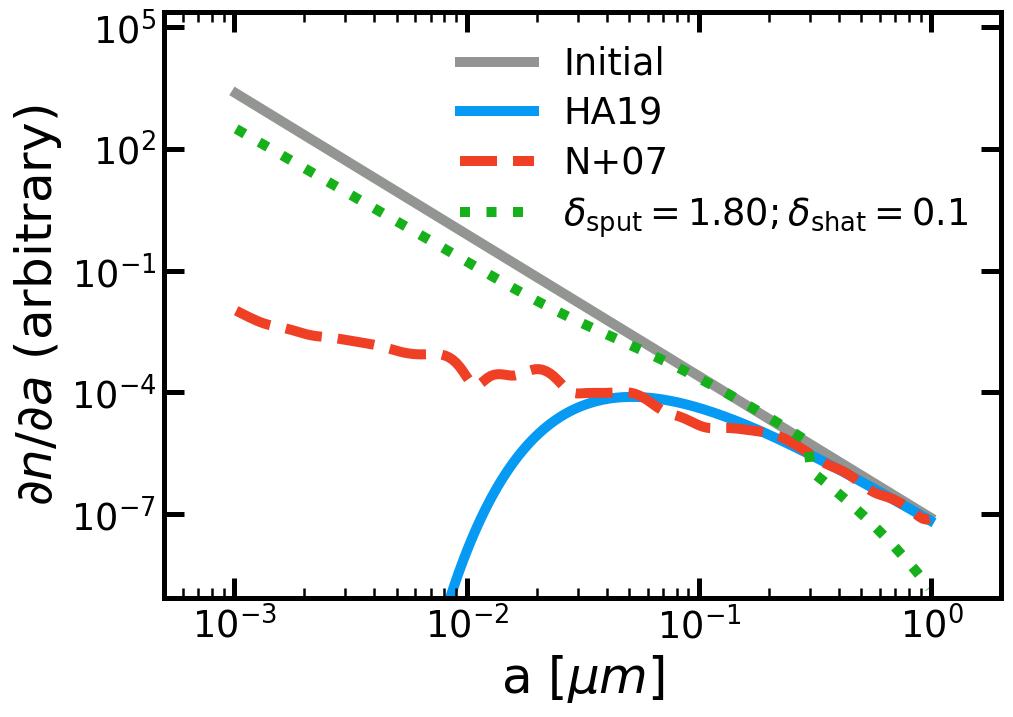

In [4]:
num_SNe = 1

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1
a_limit = [amin,amax]
bins=200
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2
a_bins = a_centers

chosen_dnda = gse.MRN_dnda
chosen_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

init_dnda=chosen_dnda(a_centers)
init_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

num_norm = 1/quad(chosen_dnda,amin,amax)[0]
mass_norm = 1/quad(chosen_dmda,amin,amax)[0]
normed_init_dnda = init_dnda*mass_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*mass_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


# Parameters for SNe destruction routine
a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 1.8;
delta_shat = 0.1;
a_frag_max = 0.3
# if amax <= a_frag_max:
#     a_frag_max=amax/2


y_limit = [np.min(normed_init_dmda*a_bins)*1E-2,np.max(normed_init_dmda*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

for k in range(0,num_SNe):


    if k == 0:
        linewidth_factor = 1
        shspsh_init_mass = init_M
        sp_init_mass = init_M
        noz_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dmda*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

        f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_shspsh(a_centers), a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        SNe_proc.set_numerical_dnda(dnda_sp(a_centers), a_centers, a_edges, normalize=False)
        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

        SNe_proc.set_numerical_dnda(dnda_noz(a_centers), a_centers, a_edges, normalize=False)
        f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')

    shspsh_fin_mass = quad(dmda_shspsh, amin, amax)[0]
    sp_fin_mass = quad(dmda_sp, amin, amax)[0]
    noz_fin_mass = quad(dmda_noz, amin, amax)[0]



    print("SNe %i"%(k+1))

    print("Sh+Sp+Sh Dest Frac 2:",f_shspsh)
    print("\t init mass %g fin mass %g"%(shspsh_init_mass,shspsh_fin_mass))
    print("Sp Only Dest Frac:",f_sp)
    print("\t init mass %g fin mass %g"%(sp_init_mass,sp_fin_mass))
    print("Nozawa+06 Dest Frac:",f_noz)
    print("\t init mass %g fin mass %g"%(noz_init_mass,noz_fin_mass))

    shspsh_init_mass = shspsh_fin_mass
    sp_init_mass = sp_fin_mass
    noz_init_mass = noz_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,color=colors[i],label='HA19', linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dmda_noz(a_bins)*a_bins,color=colors[i],label='N+07', linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dmda_shspsh(a_bins)*a_bins,color=colors[i],label=shspsh_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)

    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dmda_SNe_dest_model_comparison.pdf')

normed_init_dnda = init_dnda*num_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*num_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


y_limit = [np.min(normed_init_dnda)*1E-2,np.max(normed_init_dnda)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dn/da', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

for k in range(0,num_SNe):
    if k == 0:
        linewidth_factor = 1
        shspsh_init_mass = init_M
        sp_init_mass = init_M
        noz_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dnda,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

        f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_shspsh(a_centers), a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        SNe_proc.set_numerical_dnda(dnda_sp(a_centers), a_centers, a_edges, normalize=False)
        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

        SNe_proc.set_numerical_dnda(dnda_noz(a_centers), a_centers, a_edges, normalize=False)
        f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')

    shspsh_fin_mass = quad(dmda_shspsh, amin, amax)[0]
    sp_fin_mass = quad(dmda_sp, amin, amax)[0]
    noz_fin_mass = quad(dmda_noz, amin, amax)[0]

    shspsh_init_mass = shspsh_fin_mass
    sp_init_mass = sp_fin_mass
    noz_init_mass = noz_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dnda_sp(a_bins),color=colors[i],label='HA19', linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dnda_noz(a_bins),color=colors[i],label='N+07', linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),color=colors[i],label=shspsh_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)

    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dnda_SNe_dest_model_comparison.pdf')



### Comparing SNe model with and without shattering

SNe 1
Sh+Sp+Sh Dest Frac 2: 0.40322842299937556
	 init mass 0.999963 fin mass 0.596772
Sp Only Dest Frac: 0.4445687519065743
	 init mass 0.999963 fin mass 0.555431
SNe 2
Sh+Sp+Sh Dest Frac 2: 0.3796502481966456
	 init mass 0.596772 fin mass 0.370207
Sp Only Dest Frac: 0.25460134324343875
	 init mass 0.555431 fin mass 0.414018
SNe 3
Sh+Sp+Sh Dest Frac 2: 0.37651606627966294
	 init mass 0.370207 fin mass 0.230818
Sp Only Dest Frac: 0.21421524494674393
	 init mass 0.414018 fin mass 0.325329


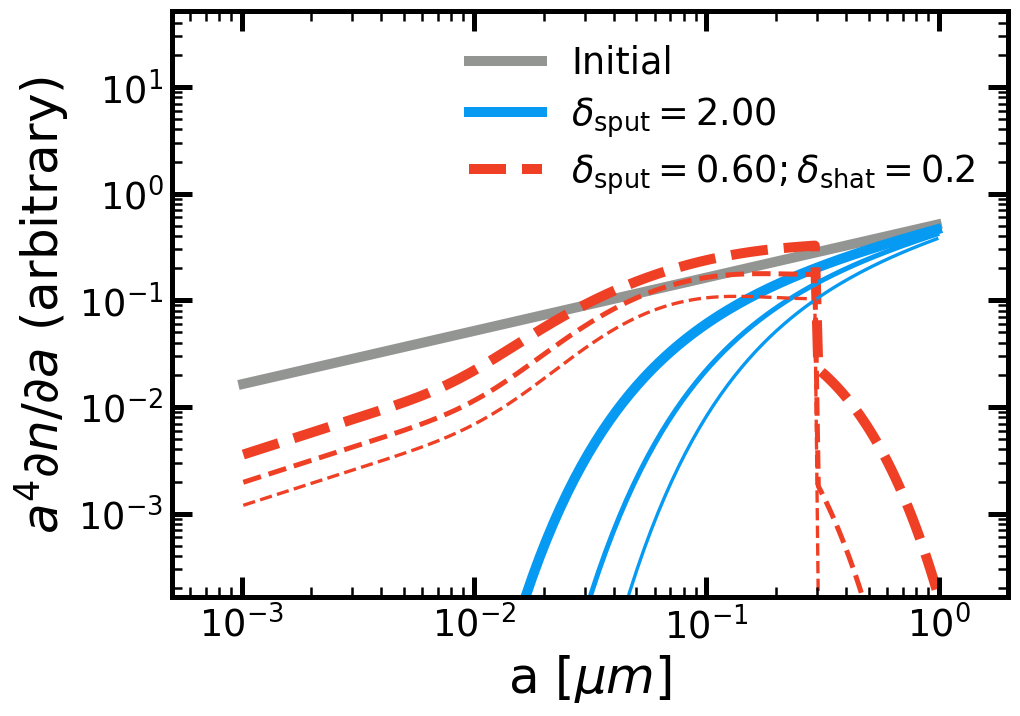

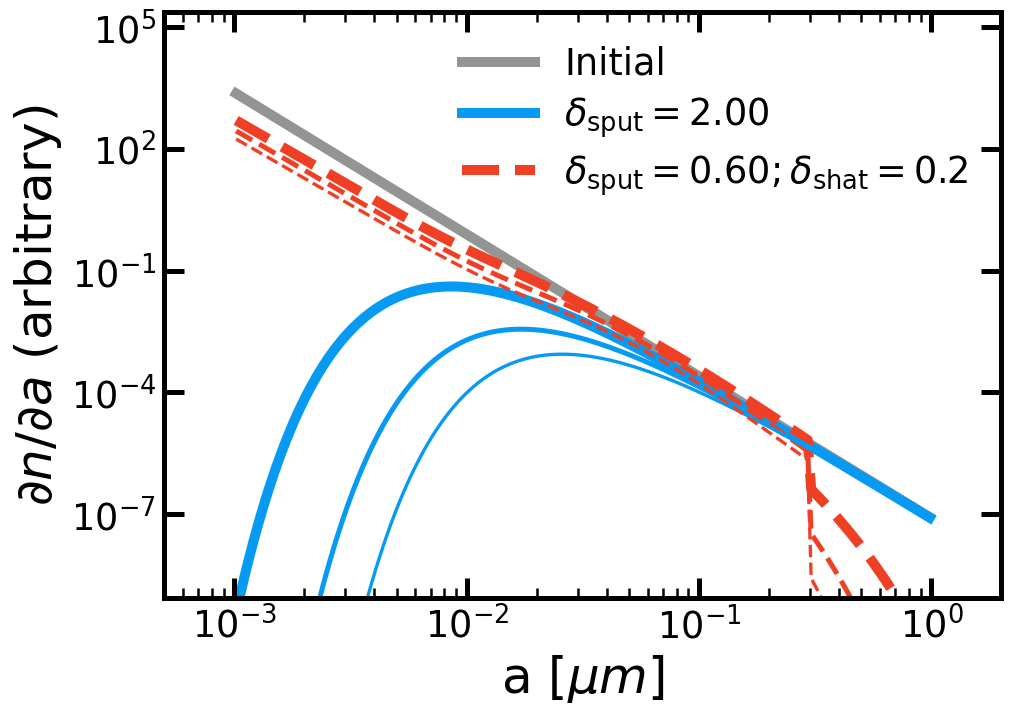

In [3]:
num_SNe = 3

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1
a_limit = [amin,amax]
bins=200
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2
a_bins = a_centers

chosen_dnda = gse.MRN_dnda
chosen_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

init_dnda=chosen_dnda(a_centers)
init_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

num_norm = 1/quad(chosen_dnda,amin,amax)[0]
mass_norm = 1/quad(chosen_dmda,amin,amax)[0]
normed_init_dnda = init_dnda*mass_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*mass_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


# Parameters for SNe destruction routine
a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.6;
delta_shat = 0.2;
a_frag_max = 0.3
# if amax <= a_frag_max:
#     a_frag_max=amax/2

delta_sput_only=2

y_limit = [np.min(normed_init_dmda*a_bins)*1E-2,np.max(normed_init_dmda*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

for k in range(0,num_SNe):


    if k == 0:
        linewidth_factor = 1
        shspsh_init_mass = init_M
        sp_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dmda*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_only, delta_shat = 0, a_sput=a_sput)
        sp_label = r'$\delta_{\rm sput}=%0.2f$'%(delta_sput_only)

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_shspsh(a_centers), a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        SNe_proc.set_numerical_dnda(dnda_sp(a_centers), a_centers, a_edges, normalize=False)
        f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_only, delta_shat = 0, a_sput=a_sput)
        sp_label = r'$\delta_{\rm sput}=%0.2f$'%(delta_sput_only)

    shspsh_fin_mass = quad(dmda_shspsh, amin, amax)[0]
    sp_fin_mass = quad(dmda_sp, amin, amax)[0]



    print("SNe %i"%(k+1))

    print("Sh+Sp+Sh Dest Frac 2:",f_shspsh)
    print("\t init mass %g fin mass %g"%(shspsh_init_mass,shspsh_fin_mass))
    print("Sp Only Dest Frac:",f_sp)
    print("\t init mass %g fin mass %g"%(sp_init_mass,sp_fin_mass))

    shspsh_init_mass = shspsh_fin_mass
    sp_init_mass = sp_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,color=colors[i],label=sp_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dmda_shspsh(a_bins)*a_bins,color=colors[i],label=shspsh_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)

    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dmda_SNe_dest_shat_vs_sput_comparison.pdf')

normed_init_dnda = init_dnda*num_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*num_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


y_limit = [np.min(normed_init_dnda)*1E-2,np.max(normed_init_dnda)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dn/da', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

for k in range(0,num_SNe):
    if k == 0:
        linewidth_factor = 1
        shspsh_init_mass = init_M
        sp_init_mass = init_M
        noz_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dnda,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        f_sp,dnda_sp,dmda_sp=f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = 0)
        sp_label = r'$\delta_{\rm sput}=%0.2f$'%(delta_sput_only)

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_shspsh(a_centers), a_centers, a_edges, normalize=False)
        f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
        shspsh_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

        SNe_proc.set_numerical_dnda(dnda_sp(a_centers), a_centers, a_edges, normalize=False)
        f_sp,dnda_sp,dmda_sp=f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = 0)
        sp_label = r'$\delta_{\rm sput}=%0.2f$'%(delta_sput_only)

    shspsh_fin_mass = quad(dmda_shspsh, amin, amax)[0]
    sp_fin_mass = quad(dmda_sp, amin, amax)[0]

    shspsh_init_mass = shspsh_fin_mass
    sp_init_mass = sp_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dnda_sp(a_bins),color=colors[i],label=sp_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),color=colors[i],label=shspsh_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)

    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dnda_SNe_dest_shat_vs_sput.pdf')



### Comparing SNe with different shattering prescriptions

#### Fiducial versus weak shattering prescriptions

/N/slate/cchoban/codes/crc_scripts/src/crc_scripts/analytical_models/grain_size_evo.py:892: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return dnda_fragments(a, C_frag) + dnda(a)*(1-eff_shat(a, delta_shat, a_shat))


SNe 1
Sh+Sp+Sh Dest Frac 2: 0.41547454282896246
	 init mass 0.999955 fin mass 0.584525
Sp Only Dest Frac: 0.4042538146836535
	 init mass 0.999955 fin mass 0.595746
SNe 2
Sh+Sp+Sh Dest Frac 2: 0.38644154359371397
	 init mass 0.584525 fin mass 0.358641
Sp Only Dest Frac: 0.3581821910011327
	 init mass 0.595746 fin mass 0.382361
SNe 3
Sh+Sp+Sh Dest Frac 2: 0.3828828301897088
	 init mass 0.358641 fin mass 0.221323
Sp Only Dest Frac: 0.34907136446801845
	 init mass 0.382361 fin mass 0.248889


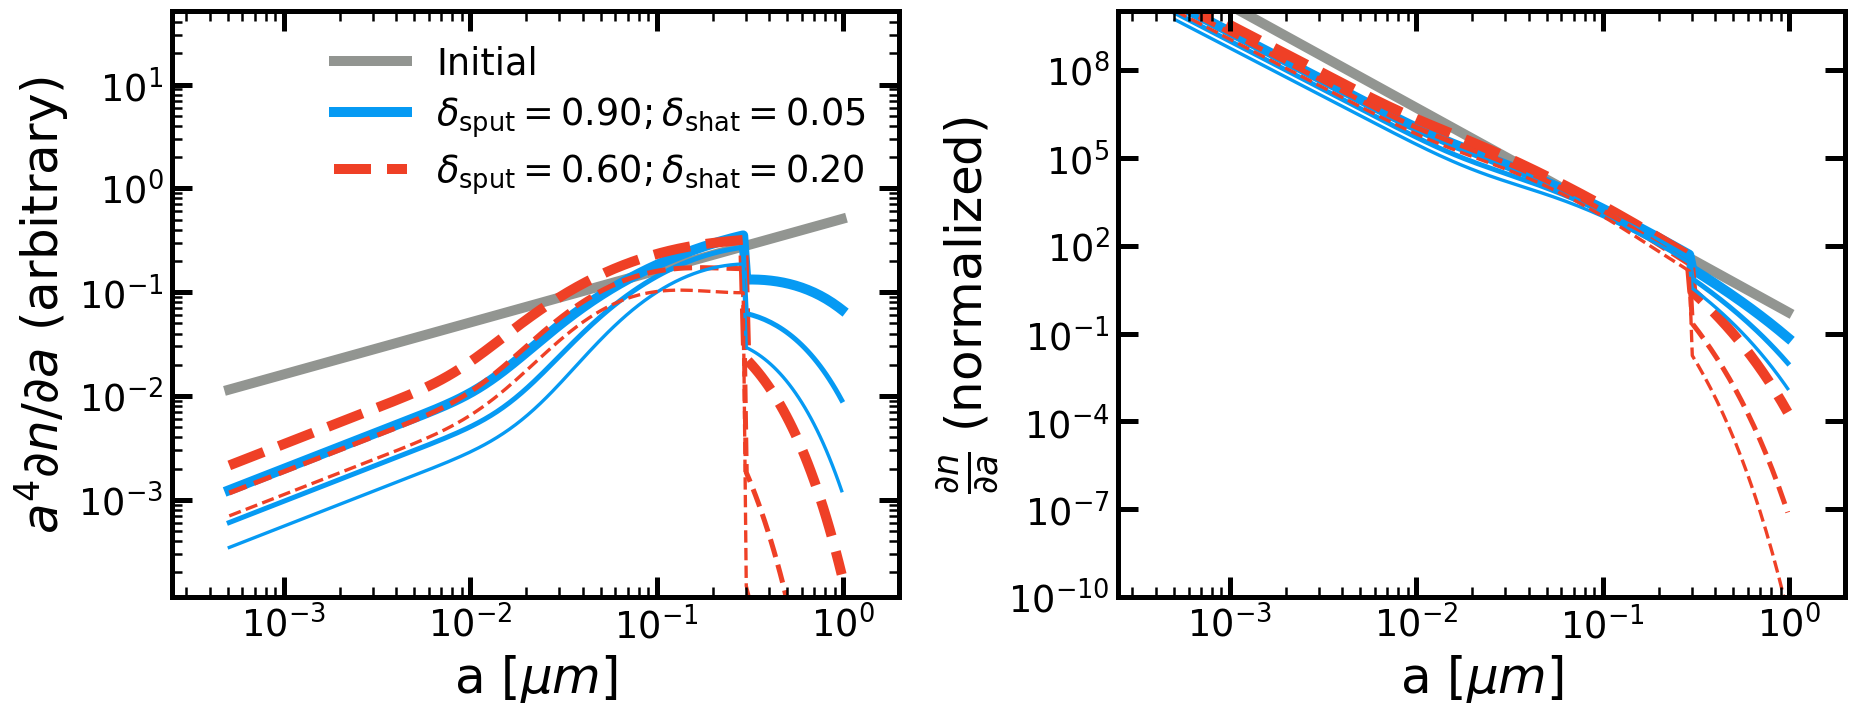

In [44]:
num_SNe = 3

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amin=5E-4
amax=1
a_limit = [amin,amax]
bins=200
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2
a_bins = a_centers

chosen_dnda = gse.MRN_dnda
chosen_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

init_dnda=chosen_dnda(a_centers)
init_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

num_norm = 1/quad(chosen_dnda,amin,amax)[0]
mass_norm = 1/quad(chosen_dmda,amin,amax)[0]
normed_init_dnda = init_dnda*mass_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*mass_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


# Parameters for SNe destruction routine
a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput_fid = 0.6;
delta_shat_fid = 0.2;
a_frag_max_fid = 0.3
# if amax <= a_frag_max:
#     a_frag_max=amax/2

delta_sput_weakshat = 0.9;
delta_shat_weakshat = 0.05;
a_frag_max_weakshat = 0.3

y_limit = [np.min(normed_init_dmda*a_bins)*1E-2,np.max(normed_init_dmda*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'grain_size', 'dm/dloga', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)
fig.set_axis(1, 'grain_size', 'dn/da_norm', x_lim=x_limit, x_log=True)

for k in range(0,num_SNe):


    if k == 0:
        linewidth_factor = 1
        fid_init_mass = init_M
        weakshat_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dmda*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
        fig.plot_line_data(1,a_bins,normed_init_dnda,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)


        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_fid,dnda_fid,dmda_fid = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_fid, delta_shat = delta_shat_fid, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max_fid)
        fid_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_fid,delta_shat_fid)

        f_weakshat,dnda_weakshat,dmda_weakshat=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_weakshat, delta_shat = delta_shat_weakshat, a_sput=a_sput, a_frag_max=a_frag_max_weakshat)
        weak_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_weakshat,delta_shat_weakshat)

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_fid(a_centers), a_centers, a_edges, normalize=False)
        f_fid,dnda_fid,dmda_fid = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_fid, delta_shat = delta_shat_fid, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max_fid)
        fid_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_fid,delta_shat_fid)

        SNe_proc.set_numerical_dnda(dnda_weakshat(a_centers), a_centers, a_edges, normalize=False)
        f_weakshat,dnda_weakshat,dmda_weakshat=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_weakshat, delta_shat = delta_shat_weakshat, a_sput=a_sput, a_frag_max=a_frag_max_weakshat)
        weak_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_weakshat,delta_shat_weakshat)

    fid_fin_mass = quad(dmda_fid, amin, amax)[0]
    weakshat_fin_mass = quad(dmda_weakshat, amin, amax)[0]



    print("SNe %i"%(k+1))

    print("Sh+Sp+Sh Dest Frac 2:",f_fid)
    print("\t init mass %g fin mass %g"%(fid_init_mass,fid_fin_mass))
    print("Sp Only Dest Frac:",f_weakshat)
    print("\t init mass %g fin mass %g"%(weakshat_init_mass,weakshat_fin_mass))

    fid_init_mass = fid_fin_mass
    weakshat_init_mass = weakshat_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dmda_weakshat(a_bins)*a_bins,color=colors[i],label=weak_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    fig.plot_line_data(1,a_bins,dnda_weakshat(a_bins),color=colors[i], linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dmda_fid(a_bins)*a_bins,color=colors[i],label=fid_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    fig.plot_line_data(1,a_bins,dnda_fid(a_bins),color=colors[i],label=fid_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)


    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dmda_SNe_dest_fid_vs_weakshat_comparison.pdf')

#### Fiducial versus larger shattering grains prescriptions

/N/slate/cchoban/codes/crc_scripts/src/crc_scripts/analytical_models/grain_size_evo.py:892: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return dnda_fragments(a, C_frag) + dnda(a)*(1-eff_shat(a, delta_shat, a_shat))
/N/slate/cchoban/codes/crc_scripts/src/crc_scripts/analytical_models/grain_size_evo.py:892: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return dnda_fragments(a, C_frag) + dnda(a)*(1-eff_shat(a, delta_shat, a_shat))


SNe 1
Fiducial Dest Frac 2: 0.41547454282896246
	 init mass 0.999955 fin mass 0.584525
Larger a_frag Dest Frac: 0.38174122131699595
	 init mass 0.999955 fin mass 0.618259
SNe 2
Fiducial Dest Frac 2: 0.38644154359371397
	 init mass 0.584525 fin mass 0.358641
Larger a_frag Dest Frac: 0.3443710065954616
	 init mass 0.618259 fin mass 0.405348
SNe 3
Fiducial Dest Frac 2: 0.3828828301897088
	 init mass 0.358641 fin mass 0.221323
Larger a_frag Dest Frac: 0.343122023264095
	 init mass 0.405348 fin mass 0.266264


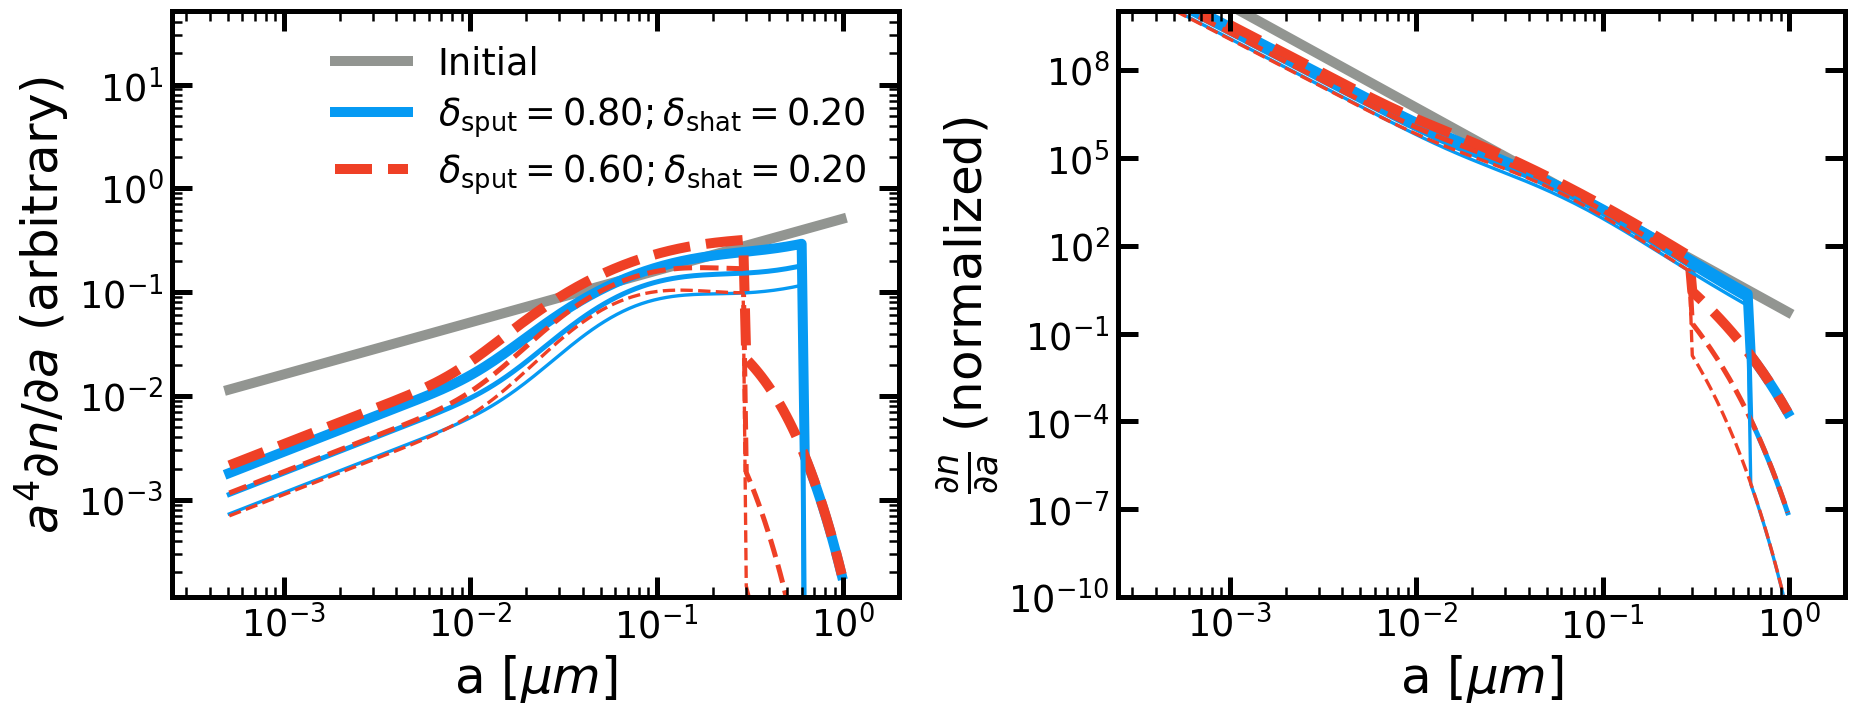

In [47]:
num_SNe = 3

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=5E-4
amax=1
a_limit = [amin,amax]
bins=200
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2
a_bins = a_centers

chosen_dnda = gse.MRN_dnda
chosen_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

init_dnda=chosen_dnda(a_centers)
init_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

num_norm = 1/quad(chosen_dnda,amin,amax)[0]
mass_norm = 1/quad(chosen_dmda,amin,amax)[0]
normed_init_dnda = init_dnda*mass_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*mass_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


# Parameters for SNe destruction routine
a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput_fid = 0.6;
delta_shat_fid = 0.2;
a_frag_max_fid = 0.3
# if amax <= a_frag_max:
#     a_frag_max=amax/2

delta_sput_largeafrag = 0.8;
delta_shat_largeafrag = 0.2;
a_frag_max_largeafrag = 0.6;

y_limit = [np.min(normed_init_dmda*a_bins)*1E-2,np.max(normed_init_dmda*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'grain_size', 'dm/dloga', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)
fig.set_axis(1, 'grain_size', 'dn/da_norm', x_lim=x_limit, x_log=True)

for k in range(0,num_SNe):


    if k == 0:
        linewidth_factor = 1
        fid_init_mass = init_M
        largeafrag_init_mass = init_M

        fig.plot_line_data(0,a_bins,normed_init_dmda*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
        fig.plot_line_data(1,a_bins,normed_init_dnda,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)


        SNe_proc = gse.SNe_Dust_Processing()
        SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
        f_fid,dnda_fid,dmda_fid = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_fid, delta_shat = delta_shat_fid, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max_fid)
        fid_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_fid,delta_shat_fid)

        f_largeafrag,dnda_largeafrag,dmda_largeafrag=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_largeafrag, delta_shat = delta_shat_largeafrag, a_sput=a_sput, a_frag_max=a_frag_max_largeafrag)
        largeafrag_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_largeafrag,delta_shat_largeafrag)

    else:
        linewidth_factor=1/(k+1)
        SNe_proc.set_numerical_dnda(dnda_fid(a_centers), a_centers, a_edges, normalize=False)
        f_fid,dnda_fid,dmda_fid = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_fid, delta_shat = delta_shat_fid, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max_fid)
        fid_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_fid,delta_shat_fid)

        SNe_proc.set_numerical_dnda(dnda_largeafrag(a_centers), a_centers, a_edges, normalize=False)
        f_largeafrag,dnda_largeafrag,dmda_largeafrag=SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput_largeafrag, delta_shat = delta_shat_largeafrag, a_sput=a_sput, a_frag_max=a_frag_max_largeafrag)
        largeafrag_label = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.2f$'%(delta_sput_largeafrag,delta_shat_largeafrag)

    fid_fin_mass = quad(dmda_fid, amin, amax)[0]
    largeafrag_fin_mass = quad(dmda_largeafrag, amin, amax)[0]



    print("SNe %i"%(k+1))

    print("Fiducial Dest Frac 2:",f_fid)
    print("\t init mass %g fin mass %g"%(fid_init_mass,fid_fin_mass))
    print("Larger a_frag Dest Frac:",f_largeafrag)
    print("\t init mass %g fin mass %g"%(largeafrag_init_mass,largeafrag_fin_mass))

    fid_init_mass = fid_fin_mass
    largeafrag_init_mass = largeafrag_fin_mass



    i=0
    fig.plot_line_data(0,a_bins,dmda_largeafrag(a_bins)*a_bins,color=colors[i],label=largeafrag_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    fig.plot_line_data(1,a_bins,dnda_largeafrag(a_bins),color=colors[i], linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    i+=1
    fig.plot_line_data(0,a_bins,dmda_fid(a_bins)*a_bins,color=colors[i],label=fid_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)
    fig.plot_line_data(1,a_bins,dnda_fid(a_bins),color=colors[i],label=fid_label, linestyle=linestyles[i],linewidth=linewidth*linewidth_factor)


    if k==0:
        fig.set_all_legends()
        
fig.save(plot_dir+'MRN_dmda_SNe_dest_fid_vs_largeafrag_comparison.pdf')

### Comparing SNe destruction for each dust species

silicates dest frac: 0.403228
carbonaceous dest frac: 0.337563
iron dest frac: 0.375594
silicates dest frac: 0.404191
carbonaceous dest frac: 0.338689
iron dest frac: 0.375604


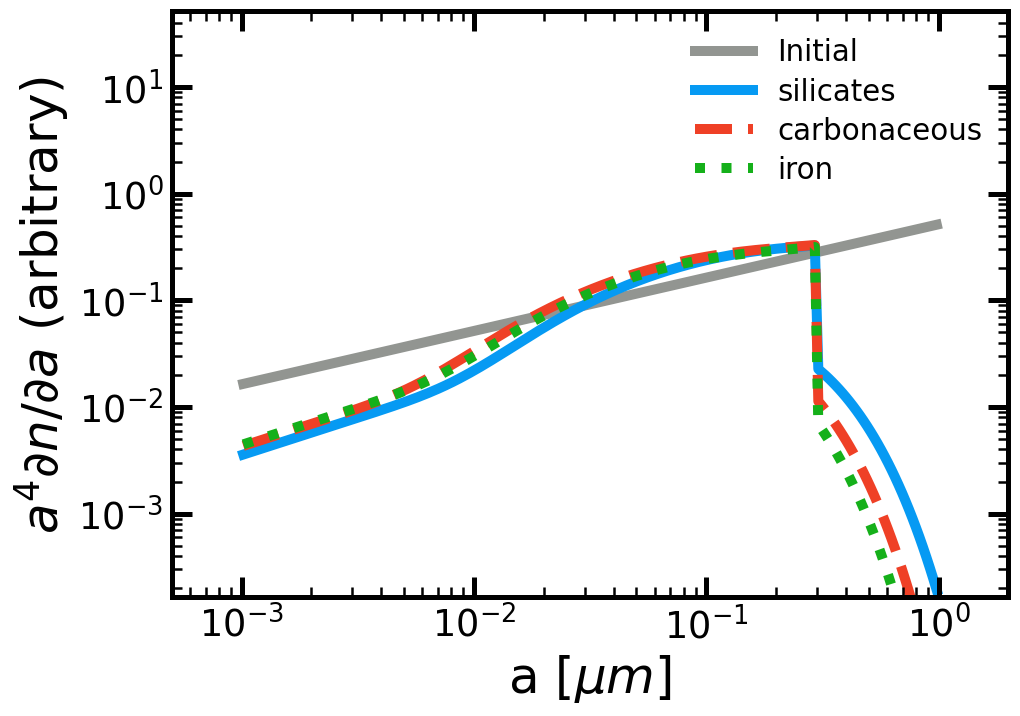

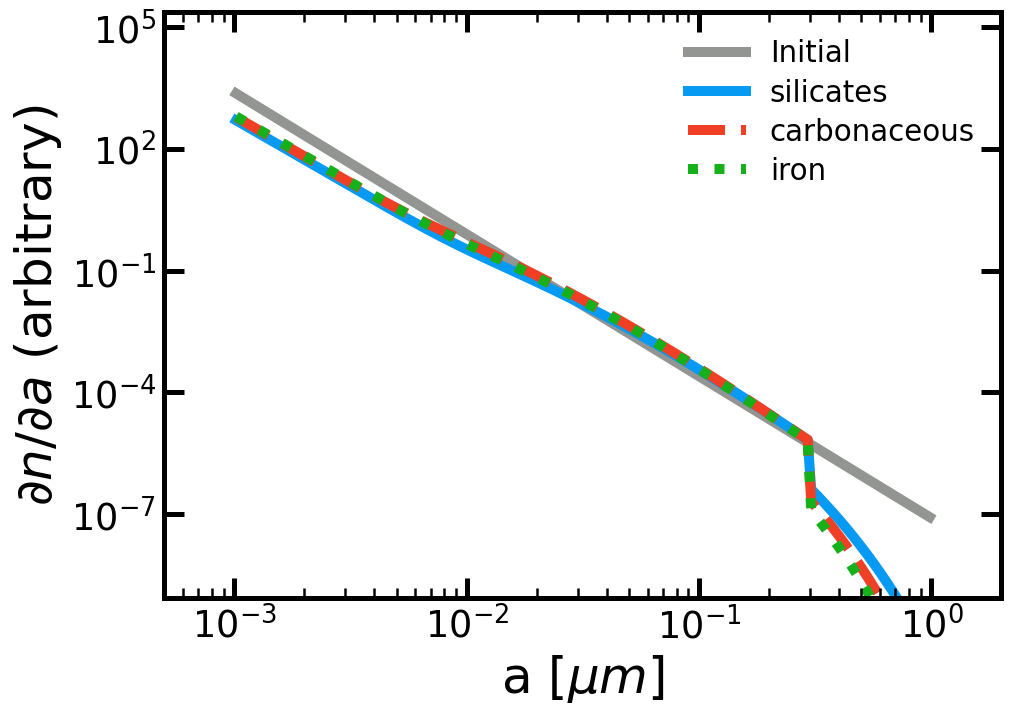

In [129]:
color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1
a_limit = [amin,amax]
bins=200
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)
a_bin_width = np.power(10,(np.log10(amax) - np.log10(amin))/bins)
a_edges = np.array([np.power(a_bin_width,i) * amin for i in range(bins+1)])
a_centers = (a_edges[1:]+a_edges[:-1])/2
a_bins = a_centers

chosen_dnda = gse.MRN_dnda
chosen_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

init_dnda=chosen_dnda(a_centers)
init_dmda= lambda a: np.power(a,3)*chosen_dnda(a)

num_norm = 1/quad(chosen_dnda,amin,amax)[0]
mass_norm = 1/quad(chosen_dmda,amin,amax)[0]
normed_init_dnda = init_dnda*mass_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*mass_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))



# Parameters for SNe destruction routine
a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.6;
delta_shat = 0.2;
a_frag_max = 0.3
# if amax <= a_frag_max:
#     a_frag_max=amax/2

y_limit = [np.min(normed_init_dmda*a_bins)*1E-2,np.max(normed_init_dmda*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dmda*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing()
SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec, delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dmda_shspsh(a_bins)*a_bins,label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'dmdloga_SNe_dest_species_comparison.pdf')



normed_init_dnda = init_dnda*num_norm
normed_init_dmda = np.power(a_centers,3)*init_dnda*num_norm
init_M = np.sum(normed_init_dmda*np.diff(a_edges))


y_limit = [np.min(normed_init_dnda)*1E-2,np.max(normed_init_dnda)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dn/da', x_lim=x_limit, x_log=True, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing()
SNe_proc.set_numerical_dnda(normed_init_dnda, a_centers, a_edges, normalize=False)
species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec, delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'dnda_SNe_dest_species_comparison.pdf')


